# Geometry Preservation Analysis
Following Ayzenberg et al. (2023) bootstrap framework.

**Measure:** Pearson correlation between T1 and T2 representational
dissimilarity matrices (6 pairwise distances from 4 categories) within
each category-selective ROI sphere. Higher = more stable geometry.

**This is inherently longitudinal** — requires 2+ sessions per subject.
There is no "cross-sectional" geometry; a single value per subject × category
captures T1→T2 stability.

**Structure:**
1. Load + descriptive stats
2. Controls lateralization (LH vs RH)
3. Bootstrap control distributions (inline)
4. Individual patient bootstrap (Ayzenberg method)
5. Group-level comparisons
6. Figures (category dots + symmetric vs asymmetric slope)
7. Supplemental Crawford

In [1]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats as sp_stats
from scipy.stats import ttest_rel, ttest_ind

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Exclusions ────────────────────────────────────────────────────────────────
EXCLUDE = ['sub-017']

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories ────────────────────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']

CAT_COLORS = {
    'face':   '#cc0066',
    'word':   '#ff8800',
    'house':  '#009900',
    'object': '#0077cc',
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred hemisphere (from selectivity, held constant across measures) ────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}
NON_PREFERRED_HEMI = {k: ('left' if v == 'right' else 'right')
                      for k, v in PREFERRED_CTRL_HEMI.items()}

# ── Bootstrap parameters ──────────────────────────────────────────────────────
N_SUBS_BOOT = 4
N_ITER      = 10000

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
RNG = np.random.default_rng(42)

# ── Metric ────────────────────────────────────────────────────────────────────
METRIC = 'geometry_preservation'

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')
print(f'METRIC: {METRIC} (higher = more stable geometry)')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']
METRIC: geometry_preservation (higher = more stable geometry)


In [2]:
# CELL 2: Load Geometry Preservation Data
# ═══════════════════════════════════════════════════════════════════════════════
# geometry CSV has one row per subject × category (only subjects with 2+ sessions).
# Same column structure as Liu CSV (subject_id, hemi_label, surgery_side, etc.)
# Filter to canonical 4 categories only.
# ═══════════════════════════════════════════════════════════════════════════════

geo_file = GEO_DIR / f'geometry_{COPE_SET}.csv'
if not geo_file.exists():
    raise FileNotFoundError(f'{geo_file}')

df_geo = pd.read_csv(geo_file)

# Filter to canonical 4 categories
df_geo = df_geo[df_geo['category'].isin(CATEGORIES)]

# Exclude sub-017
df_geo = df_geo[~df_geo['subject'].astype(str).str.contains('017')]
df_geo = df_geo[~df_geo['subject_id'].isin(EXCLUDE)]

# Split by group
ctrl = df_geo[df_geo['status'] == 'control'].copy()
otc  = df_geo[(df_geo['group'] == 'OTC') & (df_geo['hemi_label'] == 'intact')].copy()

# Derive intact_hemi for patients if not present
if 'intact_hemi' not in otc.columns:
    otc['intact_hemi'] = otc['surgery_side'].map(
        lambda s: 'right' if s == 'left' else 'left')
else:
    otc['intact_hemi'] = otc['intact_hemi'].fillna(
        otc['surgery_side'].map(lambda s: 'right' if s == 'left' else 'left'))

# Pivot controls for lateralization tests
ctrl_wide = {}
for cat in CATEGORIES:
    cat_df = ctrl[ctrl['category'] == cat][['subject_id', 'hemi_label', METRIC]]
    pivoted = cat_df.pivot(index='subject_id', columns='hemi_label', values=METRIC).dropna()
    ctrl_wide[cat] = pivoted

print(f'Controls: {ctrl["subject_id"].nunique()} subjects '
      f'({len(ctrl)} rows)')
print(f'OTC:      {otc["subject_id"].nunique()} subjects '
      f'({len(otc)} rows)')

# ── Descriptive stats ─────────────────────────────────────────────────────────
print(f'\n{"Category":<10} {"Group":<12} {"Hemi":<8} {"M":>8} {"SD":>8} {"n":>5}')
print('─' * 55)
for cat in CATEGORIES:
    ref = PREFERRED_CTRL_HEMI[cat]
    cv = ctrl[(ctrl['category'] == cat) &
              (ctrl['hemi_label'] == ref)][METRIC].values
    if len(cv) > 0:
        print(f'{cat:<10} {"ctrl pref":<12} {ref:<8} {np.mean(cv):>8.3f} {np.std(cv):>8.3f} {len(cv):>5}')
    # Also show non-preferred
    nref = NON_PREFERRED_HEMI[cat]
    cv2 = ctrl[(ctrl['category'] == cat) &
               (ctrl['hemi_label'] == nref)][METRIC].values
    if len(cv2) > 0:
        print(f'{"":<10} {"ctrl nonpref":<12} {nref:<8} {np.mean(cv2):>8.3f} {np.std(cv2):>8.3f} {len(cv2):>5}')
    pv = otc[otc['category'] == cat][METRIC].values
    if len(pv) > 0:
        print(f'{"":<10} {"OTC intact":<12} {"intact":<8} {np.mean(pv):>8.3f} {np.std(pv):>8.3f} {len(pv):>5}')

Controls: 9 subjects (67 rows)
OTC:      5 subjects (19 rows)

Category   Group        Hemi            M       SD     n
───────────────────────────────────────────────────────
face       ctrl pref    right       0.744    0.287     9
           ctrl nonpref left        0.652    0.234     9
           OTC intact   intact      0.725    0.251     5
house      ctrl pref    right       0.399    0.498     9
           ctrl nonpref left        0.486    0.562     9
           OTC intact   intact      0.080    0.434     5
object     ctrl pref    left        0.531    0.372     9
           ctrl nonpref right       0.637    0.280     9
           OTC intact   intact      0.396    0.277     5
word       ctrl pref    left        0.767    0.201     8
           ctrl nonpref right      -0.087    0.232     5
           OTC intact   intact      0.542    0.324     4


In [3]:
# CELL 3: Controls Lateralization
# ═══════════════════════════════════════════════════════════════════════════════
# Paired t-test LH vs RH per category. Higher = more stable.
# ═══════════════════════════════════════════════════════════════════════════════

n_comparisons = len(CATEGORIES)
bonferroni_alpha = 0.05 / n_comparisons

print('='*70)
print('CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)')
print('Higher geometry = more stable representational structure')
print('='*70)

lat_results = {}
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        print(f'\n  {cat}: n={len(piv)} — too few')
        continue
    lh, rh = piv['left'].values, piv['right'].values
    n = len(lh)
    diff = lh - rh
    t_stat, t_p = ttest_rel(lh, rh)
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    bonf_sig = t_p < bonferroni_alpha

    direction = 'LH > RH (LH more stable)' if diff.mean() > 0 else 'RH > LH (RH more stable)'

    lat_results[cat] = {'t': t_stat, 'p': t_p, 'd': d, 'sig': bonf_sig, 'dir': direction}

    print(f'\n  {cat}: n={n}')
    print(f'    LH: M={lh.mean():.3f} (SD={lh.std():.3f})')
    print(f'    RH: M={rh.mean():.3f} (SD={rh.std():.3f})')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {t_p:.4f}, d = {d:.3f}')
    print(f'    Bonferroni (α={bonferroni_alpha:.4f}): '
          f'{"SIGNIFICANT" if bonf_sig else "ns"} — {direction}')

# ── Category means across hemispheres ─────────────────────────────────────
print('\n' + '='*70)
print('CONTROLS: Mean geometry by category (collapsing across hemispheres)')
print('='*70)
for cat in CATEGORIES:
    all_ctrl = ctrl[ctrl['category'] == cat][METRIC].values
    if len(all_ctrl) > 0:
        cat_type = 'bilateral' if cat in BILATERAL else 'unilateral'
        print(f'  {cat} ({cat_type}): M={all_ctrl.mean():.3f} (SD={all_ctrl.std():.3f}, n={len(all_ctrl)})')

CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)
Higher geometry = more stable representational structure

  face: n=9
    LH: M=0.652 (SD=0.234)
    RH: M=0.744 (SD=0.287)
    t(8) = -0.671, p = 0.5209, d = -0.237
    Bonferroni (α=0.0125): ns — RH > LH (RH more stable)

  house: n=9
    LH: M=0.486 (SD=0.562)
    RH: M=0.399 (SD=0.498)
    t(8) = 0.409, p = 0.6930, d = 0.145
    Bonferroni (α=0.0125): ns — LH > RH (LH more stable)

  object: n=9
    LH: M=0.531 (SD=0.372)
    RH: M=0.637 (SD=0.280)
    t(8) = -0.546, p = 0.6000, d = -0.193
    Bonferroni (α=0.0125): ns — RH > LH (RH more stable)

  word: n=5
    LH: M=0.803 (SD=0.218)
    RH: M=-0.087 (SD=0.232)
    t(4) = 7.086, p = 0.0021, d = 3.543
    Bonferroni (α=0.0125): SIGNIFICANT — LH > RH (LH more stable)

CONTROLS: Mean geometry by category (collapsing across hemispheres)
  face (unilateral): M=0.698 (SD=0.266, n=18)
  house (bilateral): M=0.443 (SD=0.532, n=18)
  object (bilateral): M=0.584 (SD=0.333, n

In [4]:
# CELL 4: Bootstrap Control Geometry Distributions (inline)
# ═══════════════════════════════════════════════════════════════════════════════
# For each category × hemisphere, draw n=4 controls without replacement,
# compute mean geometry, repeat 10,000 times.
# ═══════════════════════════════════════════════════════════════════════════════

rng_boot = np.random.default_rng(42)
boot_geo = {}

print('='*70)
print(f'Bootstrapping control geometry distributions')
print(f'  n_subs={N_SUBS_BOOT}, iterations={N_ITER}, replace=False')
print('='*70)

for cat in CATEGORIES:
    for hemi_label in ['left', 'right']:
        key = f'{cat}_{hemi_label}'
        vals = ctrl[(ctrl['category'] == cat) &
                    (ctrl['hemi_label'] == hemi_label)][METRIC].dropna().values

        if len(vals) < N_SUBS_BOOT:
            print(f'  WARNING: {key} has only {len(vals)} controls, skipping')
            continue

        # Without replacement to match Ayzenberg
        boot_means = np.empty(N_ITER)
        for i in range(N_ITER):
            idx = rng_boot.choice(len(vals), size=N_SUBS_BOOT, replace=False)
            boot_means[i] = vals[idx].mean()
        boot_geo[key] = boot_means

        ci_lo = np.percentile(boot_means, 2.5)
        ci_hi = np.percentile(boot_means, 97.5)
        print(f'  {key}: n={len(vals)}, boot M={boot_means.mean():.3f}, '
              f'CI=[{ci_lo:.3f}, {ci_hi:.3f}]')

print(f'\nGenerated {len(boot_geo)} bootstrap distributions.')

Bootstrapping control geometry distributions
  n_subs=4, iterations=10000, replace=False
  face_left: n=9, boot M=0.650, CI=[0.472, 0.828]
  face_right: n=9, boot M=0.743, CI=[0.543, 0.927]
  house_left: n=9, boot M=0.482, CI=[0.006, 0.898]
  house_right: n=9, boot M=0.402, CI=[0.017, 0.751]
  object_left: n=9, boot M=0.532, CI=[0.279, 0.776]
  object_right: n=9, boot M=0.639, CI=[0.432, 0.828]
  word_left: n=8, boot M=0.768, CI=[0.619, 0.916]
  word_right: n=5, boot M=-0.086, CI=[-0.169, -0.030]

Generated 8 bootstrap distributions.


In [5]:
# CELL 5: Individual Patient Bootstrap (Ayzenberg Method)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Directionality: higher = more stable (better). BELOW CI = impaired.
# Same as summed selectivity.
#
# PRIMARY:   patient intact hemi vs. controls' PREFERRED hemi
# SECONDARY: patient intact hemi vs. controls' NON-PREFERRED hemi
#
# Reorg interpretation:
#   within preferred CI           → reorganization
#   also above non-preferred CI   → STRONG reorganization
#   below preferred CI            → impaired
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method, geometry preservation)')
print('  Higher = more stable. Below CI = IMPAIRED.')
print('  Primary:   intact vs. controls preferred hemi')
print('  Secondary: intact vs. controls non-preferred hemi')
print('  Reorg interpretation:')
print('    within preferred CI           → reorganization')
print('    also above non-preferred CI   → STRONG reorganization')
print('    below preferred CI            → impaired')
print('='*70)

corrected_rows = []

for sub in sorted(otc['subject_id'].unique()):
    sub_data = otc[otc['subject_id'] == sub]
    intact = sub_data['intact_hemi'].iloc[0]
    sub_code = sub_data['subject'].iloc[0]
    surgery_side = sub_data['surgery_side'].iloc[0]

    print(f'\n  {sub_code} (intact {intact}):')

    for cat in CATEGORIES:
        pt_row = sub_data[sub_data['category'] == cat]
        if pt_row.empty:
            print(f'    {cat}: no data')
            continue
        pt_val = pt_row[METRIC].values[0]

        pref = PREFERRED_CTRL_HEMI[cat]
        nonpref = NON_PREFERRED_HEMI[cat]
        is_reorg = (intact != pref)
        test_type = 'reorg' if is_reorg else 'normal'

        # ── Primary: vs preferred ─────────────────────────────────────
        pref_key = f'{cat}_{pref}'
        if pref_key not in boot_geo:
            print(f'    {cat}: no bootstrap for {pref_key}')
            continue
        pref_dist = boot_geo[pref_key]
        pref_pctile = float(np.mean(pref_dist <= pt_val) * 100)
        pref_ci_lo = np.percentile(pref_dist, 2.5)
        pref_ci_hi = np.percentile(pref_dist, 97.5)
        # Higher = better, so BELOW lower CI = impaired
        below_pref = pt_val < pref_ci_lo

        # ── Secondary: vs non-preferred ───────────────────────────────
        nonpref_key = f'{cat}_{nonpref}'
        if nonpref_key not in boot_geo:
            print(f'    {cat}: no bootstrap for {nonpref_key}')
            continue
        nonpref_dist = boot_geo[nonpref_key]
        nonpref_pctile = float(np.mean(nonpref_dist <= pt_val) * 100)
        nonpref_ci_lo = np.percentile(nonpref_dist, 2.5)
        nonpref_ci_hi = np.percentile(nonpref_dist, 97.5)
        above_nonpref = pt_val > nonpref_ci_hi

        # ── Interpretation ────────────────────────────────────────────
        if is_reorg:
            if not below_pref and above_nonpref:
                interp = 'STRONG reorg'
            elif not below_pref:
                interp = 'reorg (within preferred)'
            else:
                interp = 'impaired'
        else:
            if not below_pref:
                interp = 'normal'
            else:
                interp = 'impaired'

        pref_marker = '*' if below_pref else '-'
        nonpref_marker = '+' if above_nonpref else '-'

        print(f'    {cat} [{test_type}]: val={pt_val:.3f}  '
              f'vs pref({pref})={pref_pctile:.0f}%{pref_marker}  '
              f'vs nonpref({nonpref})={nonpref_pctile:.0f}%{nonpref_marker}  '
              f'→ {interp}')

        corrected_rows.append({
            'sub': sub, 'subject': sub_code,
            'group': 'OTC', 'intact_hemi': intact,
            'surgery_side': surgery_side,
            'category': cat, 'value': pt_val, 'test_type': test_type,
            'pref_hemi': pref, 'pref_pctile': pref_pctile,
            'pref_ci_lo': pref_ci_lo, 'pref_ci_hi': pref_ci_hi,
            'below_pref': below_pref,
            'nonpref_hemi': nonpref, 'nonpref_pctile': nonpref_pctile,
            'nonpref_ci_lo': nonpref_ci_lo, 'nonpref_ci_hi': nonpref_ci_hi,
            'above_nonpref': above_nonpref,
            'interpretation': interp,
        })

df_corrected = pd.DataFrame(corrected_rows)

# ── Summary: Reorganization tests ─────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Reorganization tests (intact = non-preferred hemi)')
print('  "within_pref" = NOT below preferred CI = reorganized geometry')
print('='*70)
grp = df_corrected[df_corrected['test_type'] == 'reorg']
if not grp.empty:
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"above_nonpref":>14} {"STRONG":>7}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        if n == 0:
            continue
        n_within = int((~c['below_pref']).sum())
        n_above = int(c['above_nonpref'].sum())
        n_strong = int(((~c['below_pref']) & c['above_nonpref']).sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_above:>10}/{n:<3} {n_strong:>4}/{n}')

# ── Summary: Normal tests ─────────────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Normal tests (intact = preferred hemi)')
print('  "within_pref" = NOT below preferred CI = normal geometry')
print('='*70)
grp = df_corrected[df_corrected['test_type'] == 'normal']
if not grp.empty:
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"impaired":>9}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        if n == 0:
            continue
        n_within = int((~c['below_pref']).sum())
        n_impaired = int(c['below_pref'].sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_impaired:>5}/{n}')

INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method, geometry preservation)
  Higher = more stable. Below CI = IMPAIRED.
  Primary:   intact vs. controls preferred hemi
  Secondary: intact vs. controls non-preferred hemi
  Reorg interpretation:
    within preferred CI           → reorganization
    also above non-preferred CI   → STRONG reorganization
    below preferred CI            → impaired

  OTC004 (intact left):
    face [reorg]: val=0.772  vs pref(right)=52%-  vs nonpref(left)=90%-  → reorg (within preferred)
    house [reorg]: val=-0.143  vs pref(right)=0%*  vs nonpref(left)=0%-  → impaired
    object [normal]: val=0.590  vs pref(left)=54%-  vs nonpref(right)=36%-  → normal
    word [normal]: val=0.749  vs pref(left)=40%-  vs nonpref(right)=100%+  → normal

  OTC008 (intact left):
    face [reorg]: val=0.236  vs pref(right)=0%*  vs nonpref(left)=0%-  → impaired
    house [reorg]: val=-0.027  vs pref(right)=2%*  vs nonpref(left)=2%-  → impaired
    object [normal]: val=-0.137  vs p

In [6]:
# CELL 6: Group-Level Comparisons
# ═══════════════════════════════════════════════════════════════════════════════
#
# 6a: OTC group mean vs. bootstrapped preferred-hemi controls (per category)
# 6b: Within-group hemisphere differences
# ═══════════════════════════════════════════════════════════════════════════════

# ── 6a: Group mean vs bootstrap ──────────────────────────────────────────────
print('='*70)
print('6a. GROUP-LEVEL BOOTSTRAP: OTC group mean vs controls preferred hemi')
print('    Higher = more stable. Below CI = impaired.')
print('='*70)

print(f'\n--- OTC vs Controls (preferred hemi) ---')
for cat in CATEGORIES:
    pt_vals = otc[otc['category'] == cat][METRIC].dropna().values
    if len(pt_vals) == 0:
        continue
    pt_mean = pt_vals.mean()

    pref = PREFERRED_CTRL_HEMI[cat]
    ctrl_vals = ctrl[(ctrl['category'] == cat) &
                     (ctrl['hemi_label'] == pref)][METRIC].values
    ctrl_mean = ctrl_vals.mean()
    ctrl_sd = ctrl_vals.std(ddof=1)

    boot_key = f'{cat}_{pref}'
    boot_dist = boot_geo[boot_key]
    pt_pctile = float(np.mean(boot_dist <= pt_mean) * 100)
    ci_lo = np.percentile(boot_dist, 2.5)
    ci_hi = np.percentile(boot_dist, 97.5)
    below = pt_mean < ci_lo

    d = (pt_mean - ctrl_mean) / ctrl_sd if ctrl_sd > 0 else np.nan
    sig_str = '**BELOW CI (impaired)**' if below else 'within CI'

    cat_type = 'bilateral' if cat in BILATERAL else 'unilateral'
    print(f'  {cat} ({cat_type}): pt M={pt_mean:.3f} (n={len(pt_vals)}), '
          f'ctrl {pref} M={ctrl_mean:.3f} (n={len(ctrl_vals)})')
    print(f'    pctile={pt_pctile:.1f}%, CI=[{ci_lo:.3f}, {ci_hi:.3f}] — {sig_str}, d={d:.3f}')

# ── 6b: Within-group hemisphere differences ──────────────────────────────────
print('\n' + '='*70)
print('6b. WITHIN-GROUP HEMISPHERE DIFFERENCES')
print('='*70)

# Controls: paired t-test
print('\n--- Controls (paired t-test, LH vs RH) ---')
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    t, p = ttest_rel(piv['left'].values, piv['right'].values)
    diff = piv['left'].values - piv['right'].values
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {cat}: LH M={piv["left"].mean():.3f}, RH M={piv["right"].mean():.3f}, '
          f't({len(piv)-1})={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

# OTC: independent t-test (L vs R resection)
print(f'\n--- OTC (independent t-test, L vs R resection) ---')
for cat in CATEGORIES:
    l_vals = otc[(otc['category'] == cat) &
                 (otc['surgery_side'] == 'left')][METRIC].dropna().values
    r_vals = otc[(otc['category'] == cat) &
                 (otc['surgery_side'] == 'right')][METRIC].dropna().values
    if len(l_vals) < 2 or len(r_vals) < 2:
        print(f'  {cat}: L resec n={len(l_vals)}, R resec n={len(r_vals)} — too few')
        continue
    t, p = ttest_ind(l_vals, r_vals)
    pooled_sd = np.sqrt(((len(l_vals)-1)*l_vals.std(ddof=1)**2 +
                         (len(r_vals)-1)*r_vals.std(ddof=1)**2) /
                        (len(l_vals)+len(r_vals)-2))
    d = (l_vals.mean() - r_vals.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {cat}: L resec(intact RH) M={l_vals.mean():.3f}(n={len(l_vals)}), '
          f'R resec(intact LH) M={r_vals.mean():.3f}(n={len(r_vals)}), '
          f't={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

6a. GROUP-LEVEL BOOTSTRAP: OTC group mean vs controls preferred hemi
    Higher = more stable. Below CI = impaired.

--- OTC vs Controls (preferred hemi) ---
  face (unilateral): pt M=0.725 (n=5), ctrl right M=0.744 (n=9)
    pctile=44.9%, CI=[0.543, 0.927] — within CI, d=-0.064
  house (bilateral): pt M=0.080 (n=5), ctrl right M=0.399 (n=9)
    pctile=3.9%, CI=[0.017, 0.751] — within CI, d=-0.604
  object (bilateral): pt M=0.396 (n=5), ctrl left M=0.531 (n=9)
    pctile=25.4%, CI=[0.279, 0.776] — within CI, d=-0.342
  word (unilateral): pt M=0.542 (n=4), ctrl left M=0.767 (n=8)
    pctile=0.0%, CI=[0.619, 0.916] — **BELOW CI (impaired)**, d=-1.047

6b. WITHIN-GROUP HEMISPHERE DIFFERENCES

--- Controls (paired t-test, LH vs RH) ---
  face: LH M=0.652, RH M=0.744, t(8)=-0.671, p=0.5209 ns, d=-0.237
  house: LH M=0.486, RH M=0.399, t(8)=0.409, p=0.6930 ns, d=0.145
  object: LH M=0.531, RH M=0.637, t(8)=-0.546, p=0.6000 ns, d=-0.193
  word: LH M=0.803, RH M=-0.087, t(4)=7.086, p=0.0021 **

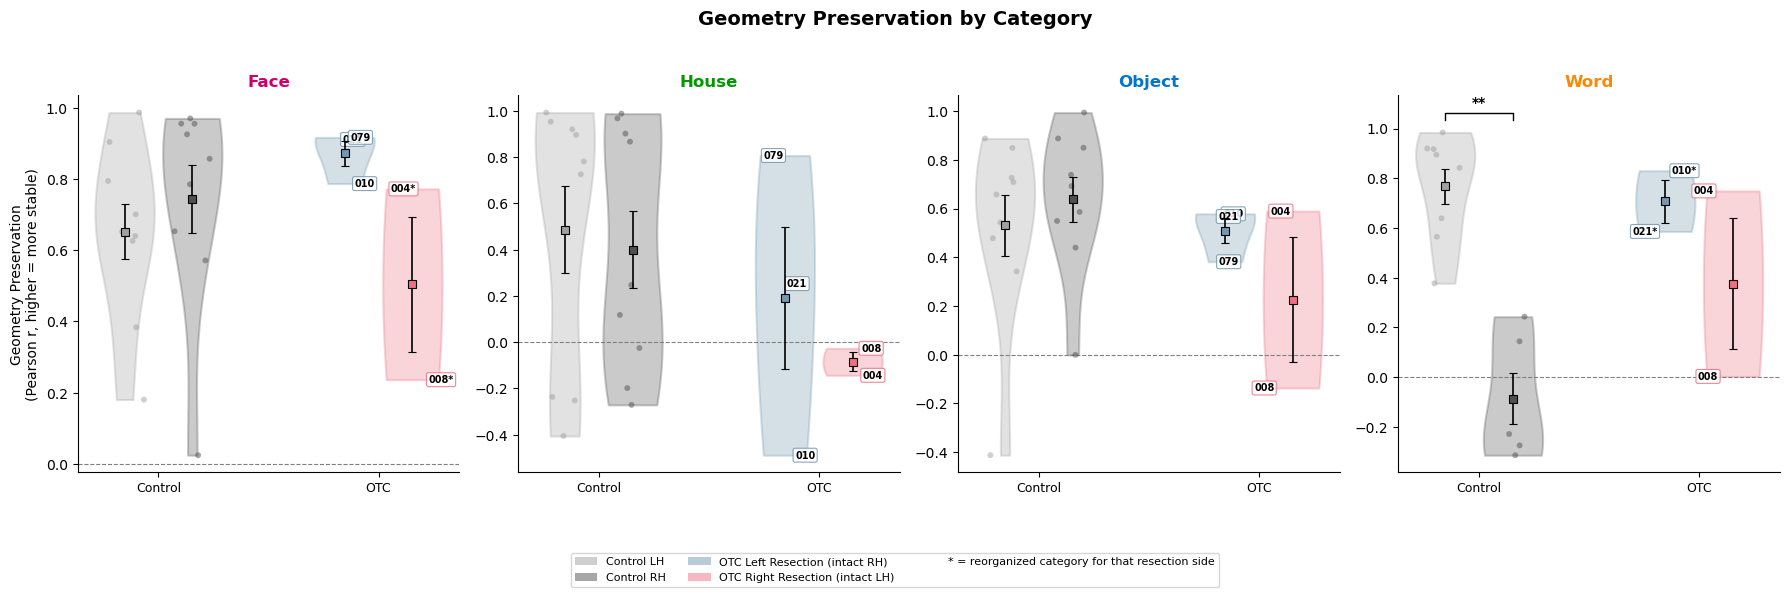

Saved: fig_geometry_by_category_differential.png


In [7]:
# CELL 7: Figure — Geometry Preservation by Category
# ═══════════════════════════════════════════════════════════════════════════════
# Violin + jitter for controls LH/RH, labeled badges for OTC patients.
# Same layout as selectivity and Liu distinctiveness figures.
# ═══════════════════════════════════════════════════════════════════════════════

n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['subject'])
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket ────────────────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        all_vals = np.concatenate([cl, cr]) if len(cl) > 0 and len(cr) > 0 else np.array([0])
        y_max = all_vals.max()
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y * 1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5])
    ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
    if col_idx == 0:
        ax.set_ylabel('Geometry Preservation\n(Pearson r, higher = more stable)')

legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Geometry Preservation by Category', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_geometry_by_category_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_geometry_by_category_{COPE_SET}.png')

ASYMMETRIC vs SYMMETRIC GEOMETRY
  Asymmetric = face, word (unilateral)
  Symmetric  = house, object (bilateral)
  diff = symmetric - asymmetric (negative = symmetric worse)

OTC (n=5):
  Asymmetric: M=0.671 (SD=0.315)
  Symmetric:  M=0.238 (SD=0.272)
  Diff (sym-asym): M=-0.432 (SD=0.221)
  Paired t(4)=-4.378, p=0.0119, d=-1.958

  Per patient:
    OTC004: asym=0.760, sym=0.223, diff=-0.537 ↓
    OTC008: asym=0.119, sym=-0.082, diff=-0.201 ↓
    OTC010: asym=0.808, sym=0.045, diff=-0.764 ↓
    OTC021: asym=0.748, sym=0.410, diff=-0.338 ↓
    OTC079: asym=0.917, sym=0.594, diff=-0.322 ↓

Controls (n=9):
  Asymmetric: M=0.584 (SD=0.197)
  Symmetric:  M=0.513 (SD=0.291)
  Diff (sym-asym): M=-0.071 (SD=0.256)
  Paired t(8)=-0.830, p=0.4304, d=-0.277



Difference-of-differences (OTC diff - Control diff):
  OTC diff:     -0.432
  Control diff: -0.071
  Diff-of-diff: -0.362  95% CI [-0.602, -0.134]
  → SIGNIFICANT


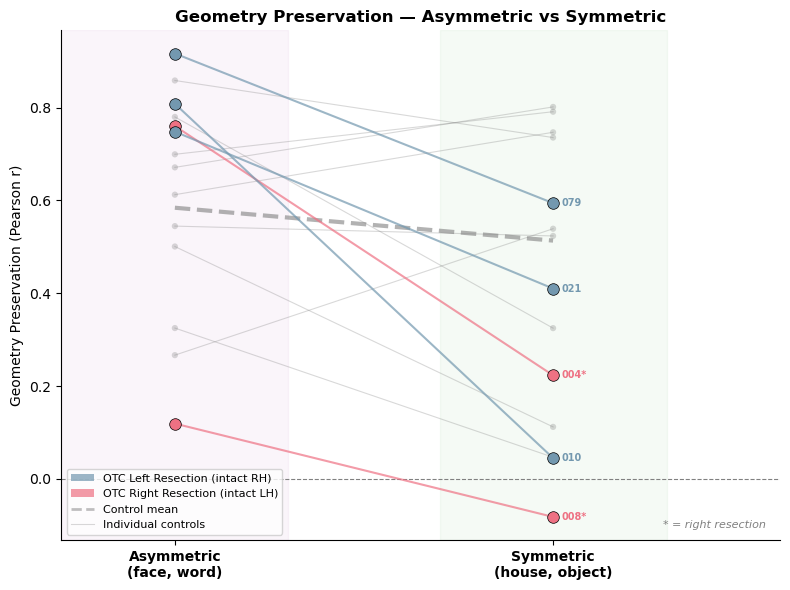

Saved: fig_geometry_slope_differential.png


In [8]:
# CELL 8: Figure — Symmetric vs Asymmetric Slope Plot
# ═══════════════════════════════════════════════════════════════════════════════
# Paired slope: asymmetric (face, word) mean → symmetric (house, object) mean
# per patient. This is the headline visualization.
#
# Also computes the asymmetric–symmetric difference for each patient and
# bootstraps the group difference.
# ═══════════════════════════════════════════════════════════════════════════════

# Compute per-patient asymmetric and symmetric means
slope_rows = []
for sub in sorted(otc['subject_id'].unique()):
    sub_df = otc[otc['subject_id'] == sub]
    sub_code = sub_df['subject'].iloc[0]
    side = sub_df['surgery_side'].iloc[0]

    asym_vals = [sub_df[sub_df['category'] == c][METRIC].values for c in UNILATERAL]
    sym_vals  = [sub_df[sub_df['category'] == c][METRIC].values for c in BILATERAL]

    asym = np.nanmean([v[0] for v in asym_vals if len(v)])
    sym  = np.nanmean([v[0] for v in sym_vals if len(v)])

    if np.isfinite(asym) and np.isfinite(sym):
        slope_rows.append({
            'subject': sub_code, 'surgery_side': side,
            'asymmetric': asym, 'symmetric': sym,
            'diff': sym - asym,  # negative = symmetric worse
        })

df_slope = pd.DataFrame(slope_rows)

# Same for controls (average across L and R hemispheres first, then asym/sym)
ctrl_slope_rows = []
for sub in sorted(ctrl['subject_id'].unique()):
    sub_df = ctrl[ctrl['subject_id'] == sub]

    asym_vals = []
    for c in UNILATERAL:
        cv = sub_df[sub_df['category'] == c][METRIC].values
        if len(cv) > 0:
            asym_vals.append(cv.mean())  # average across hemispheres
    sym_vals = []
    for c in BILATERAL:
        cv = sub_df[sub_df['category'] == c][METRIC].values
        if len(cv) > 0:
            sym_vals.append(cv.mean())

    if len(asym_vals) > 0 and len(sym_vals) > 0:
        asym = np.mean(asym_vals)
        sym  = np.mean(sym_vals)
        ctrl_slope_rows.append({
            'subject': sub_df['subject'].iloc[0],
            'asymmetric': asym, 'symmetric': sym,
            'diff': sym - asym,
        })

df_ctrl_slope = pd.DataFrame(ctrl_slope_rows)

# ── Statistics ────────────────────────────────────────────────────────────
print('='*70)
print('ASYMMETRIC vs SYMMETRIC GEOMETRY')
print('  Asymmetric = face, word (unilateral)')
print('  Symmetric  = house, object (bilateral)')
print('  diff = symmetric - asymmetric (negative = symmetric worse)')
print('='*70)

if len(df_slope) > 0:
    print(f'\nOTC (n={len(df_slope)}):')
    print(f'  Asymmetric: M={df_slope["asymmetric"].mean():.3f} (SD={df_slope["asymmetric"].std():.3f})')
    print(f'  Symmetric:  M={df_slope["symmetric"].mean():.3f} (SD={df_slope["symmetric"].std():.3f})')
    print(f'  Diff (sym-asym): M={df_slope["diff"].mean():.3f} (SD={df_slope["diff"].std():.3f})')
    # Paired t-test
    t, p = ttest_rel(df_slope['symmetric'].values, df_slope['asymmetric'].values)
    d = df_slope['diff'].mean() / df_slope['diff'].std() if df_slope['diff'].std() > 0 else np.nan
    print(f'  Paired t({len(df_slope)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

    # Per patient
    print(f'\n  Per patient:')
    for _, r in df_slope.iterrows():
        direction = '↓' if r['diff'] < 0 else '↑'
        print(f'    {r["subject"]}: asym={r["asymmetric"]:.3f}, sym={r["symmetric"]:.3f}, '
              f'diff={r["diff"]:+.3f} {direction}')

if len(df_ctrl_slope) > 0:
    print(f'\nControls (n={len(df_ctrl_slope)}):')
    print(f'  Asymmetric: M={df_ctrl_slope["asymmetric"].mean():.3f} (SD={df_ctrl_slope["asymmetric"].std():.3f})')
    print(f'  Symmetric:  M={df_ctrl_slope["symmetric"].mean():.3f} (SD={df_ctrl_slope["symmetric"].std():.3f})')
    print(f'  Diff (sym-asym): M={df_ctrl_slope["diff"].mean():.3f} (SD={df_ctrl_slope["diff"].std():.3f})')
    t, p = ttest_rel(df_ctrl_slope['symmetric'].values, df_ctrl_slope['asymmetric'].values)
    d = df_ctrl_slope['diff'].mean() / df_ctrl_slope['diff'].std() if df_ctrl_slope['diff'].std() > 0 else np.nan
    print(f'  Paired t({len(df_ctrl_slope)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

# ── Bootstrap difference-of-differences ───────────────────────────────────
if len(df_slope) > 0 and len(df_ctrl_slope) > 0:
    otc_diffs  = df_slope['diff'].values
    ctrl_diffs = df_ctrl_slope['diff'].values

    rng_dd = np.random.default_rng(42)
    n_boot_dd = 100000
    boot_dd = np.empty(n_boot_dd)
    for i in range(n_boot_dd):
        otc_sample  = rng_dd.choice(otc_diffs, size=len(otc_diffs), replace=True)
        ctrl_sample = rng_dd.choice(ctrl_diffs, size=len(ctrl_diffs), replace=True)
        boot_dd[i]  = otc_sample.mean() - ctrl_sample.mean()

    dd_mean = otc_diffs.mean() - ctrl_diffs.mean()
    dd_ci   = np.percentile(boot_dd, [2.5, 97.5])
    sig     = 'SIGNIFICANT' if dd_ci[0] > 0 or dd_ci[1] < 0 else 'not significant'

    print(f'\nDifference-of-differences (OTC diff - Control diff):')
    print(f'  OTC diff:     {otc_diffs.mean():.3f}')
    print(f'  Control diff: {ctrl_diffs.mean():.3f}')
    print(f'  Diff-of-diff: {dd_mean:.3f}  95% CI [{dd_ci[0]:.3f}, {dd_ci[1]:.3f}]')
    print(f'  → {sig}')

# ── Slope Figure ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Plot control slopes (gray, background)
for _, r in df_ctrl_slope.iterrows():
    ax.plot([0, 1], [r['asymmetric'], r['symmetric']],
            color='gray', linewidth=0.8, alpha=0.3, zorder=1)
    ax.scatter([0, 1], [r['asymmetric'], r['symmetric']],
               color='gray', s=20, alpha=0.3, zorder=1, edgecolors='none')

# Control group mean
if len(df_ctrl_slope) > 0:
    ax.plot([0, 1],
            [df_ctrl_slope['asymmetric'].mean(), df_ctrl_slope['symmetric'].mean()],
            color='gray', linewidth=3, alpha=0.6, zorder=2, linestyle='--')

# Plot OTC slopes
for _, r in df_slope.iterrows():
    col = OTC_L if r['surgery_side'] == 'left' else OTC_R
    lbl = short_name(r['subject'])
    star = '*' if r['surgery_side'] == 'right' else ''

    ax.plot([0, 1], [r['asymmetric'], r['symmetric']],
            color=col, linewidth=1.5, alpha=0.7, zorder=3)
    ax.scatter(0, r['asymmetric'], color=col, s=70, zorder=4,
               edgecolors='black', linewidth=0.5)
    ax.scatter(1, r['symmetric'], color=col, s=70, zorder=4,
               edgecolors='black', linewidth=0.5)
    ax.annotate(f'{lbl}{star}', (1, r['symmetric']),
                fontsize=7, fontweight='bold', ha='left', va='center',
                xytext=(6, 0), textcoords='offset points', color=col)

# Shading
ax.axvspan(-0.3, 0.3, alpha=0.04, color='purple', zorder=0)
ax.axvspan(0.7, 1.3, alpha=0.04, color='green', zorder=0)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Asymmetric\n(face, word)',
                     'Symmetric\n(house, object)'],
                    fontsize=10, fontweight='bold')
ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=10)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlim(-0.3, 1.6)
ax.set_title('Geometry Preservation — Asymmetric vs Symmetric',
             fontsize=12, fontweight='bold')

legend_elements = [
    Patch(facecolor=OTC_L, alpha=0.7, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R, alpha=0.7, label='OTC Right Resection (intact LH)'),
    Line2D([0], [0], color='gray', linewidth=2, alpha=0.5,
           linestyle='--', label='Control mean'),
    Line2D([0], [0], color='gray', linewidth=0.8, alpha=0.3,
           label='Individual controls'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, frameon=True)

ax.annotate('* = right resection', xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(str(FIG_DIR / f'fig_geometry_slope_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_geometry_slope_{COPE_SET}.png')

In [9]:
# CELL 6c: Per-Category Bootstrap — OTC vs Control Difference
# ═══════════════════════════════════════════════════════════════════════════════
# For each category: bootstrap the difference (OTC mean - Control pref-hemi mean).
# If 95% CI excludes zero → the category-level drop is individually significant.
# 100,000 iterations.
# ═══════════════════════════════════════════════════════════════════════════════

N_BOOT_DIFF = 100000
rng_diff = np.random.default_rng(42)

print('='*70)
print('6c. PER-CATEGORY BOOTSTRAP: OTC mean - Control preferred hemi mean')
print('    Negative = OTC less stable. CI excludes 0 → significant drop.')
print('='*70)

cat_diff_results = {}
for cat in CATEGORIES:
    otc_vals  = otc[otc['category'] == cat][METRIC].dropna().values
    pref      = PREFERRED_CTRL_HEMI[cat]
    ctrl_vals = ctrl[(ctrl['category'] == cat) &
                     (ctrl['hemi_label'] == pref)][METRIC].dropna().values

    if len(otc_vals) < 2 or len(ctrl_vals) < 2:
        print(f'  {cat}: too few (OTC n={len(otc_vals)}, ctrl n={len(ctrl_vals)})')
        continue

    boot_diff = np.empty(N_BOOT_DIFF)
    for i in range(N_BOOT_DIFF):
        o = rng_diff.choice(otc_vals, size=len(otc_vals), replace=True)
        c = rng_diff.choice(ctrl_vals, size=len(ctrl_vals), replace=True)
        boot_diff[i] = o.mean() - c.mean()

    ci_lo = np.percentile(boot_diff, 2.5)
    ci_hi = np.percentile(boot_diff, 97.5)
    observed = otc_vals.mean() - ctrl_vals.mean()
    sig = ci_lo > 0 or ci_hi < 0
    sig_str = 'SIGNIFICANT' if sig else 'not significant'
    cat_type = 'bilateral' if cat in BILATERAL else 'unilateral'

    cat_diff_results[cat] = {
        'observed': observed, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'sig': sig
    }

    print(f'\n  {cat} ({cat_type}):')
    print(f'    OTC M={otc_vals.mean():.3f} (n={len(otc_vals)}), '
          f'Ctrl M={ctrl_vals.mean():.3f} (n={len(ctrl_vals)})')
    print(f'    Diff = {observed:+.3f}  95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]')
    print(f'    → {sig_str}')

# ── Summary table ─────────────────────────────────────────────────────────
print('\n' + '─'*70)
print(f'{"Category":<10} {"Type":<12} {"Diff":>8} {"CI_lo":>8} {"CI_hi":>8} {"Sig":>5}')
print('─'*70)
for cat in CATEGORIES:
    if cat not in cat_diff_results:
        continue
    r = cat_diff_results[cat]
    cat_type = 'bilateral' if cat in BILATERAL else 'unilateral'
    sig_mark = '*' if r['sig'] else ''
    print(f'{cat:<10} {cat_type:<12} {r["observed"]:>+8.3f} {r["ci_lo"]:>+8.3f} '
          f'{r["ci_hi"]:>+8.3f} {sig_mark:>5}')

6c. PER-CATEGORY BOOTSTRAP: OTC mean - Control preferred hemi mean
    Negative = OTC less stable. CI excludes 0 → significant drop.

  face (unilateral):
    OTC M=0.725 (n=5), Ctrl M=0.744 (n=9)
    Diff = -0.019  95% CI [-0.316, +0.264]
    → not significant



  house (bilateral):
    OTC M=0.080 (n=5), Ctrl M=0.399 (n=9)
    Diff = -0.319  95% CI [-0.804, +0.193]
    → not significant

  object (bilateral):
    OTC M=0.396 (n=5), Ctrl M=0.531 (n=9)
    Diff = -0.135  95% CI [-0.481, +0.208]
    → not significant

  word (unilateral):
    OTC M=0.542 (n=4), Ctrl M=0.767 (n=8)
    Diff = -0.225  95% CI [-0.601, +0.081]
    → not significant

──────────────────────────────────────────────────────────────────────
Category   Type             Diff    CI_lo    CI_hi   Sig
──────────────────────────────────────────────────────────────────────
face       unilateral     -0.019   -0.316   +0.264      
house      bilateral      -0.319   -0.804   +0.193      
object     bilateral      -0.135   -0.481   +0.208      
word       unilateral     -0.225   -0.601   +0.081      


In [10]:
# SUPPLEMENTAL: Crawford-Howell Single-Case Tests (Geometry)
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return np.array([], dtype=bool)
    order = np.argsort(pvals)
    ranked = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


print('='*70)
print('SUPPLEMENTAL: Crawford-Howell single-case tests (Geometry preservation)')
print('='*70)

craw_rows = []
for cat in CATEGORIES:
    ref = PREFERRED_CTRL_HEMI[cat]
    ctrl_vals = ctrl[(ctrl['category'] == cat) &
                     (ctrl['hemi_label'] == ref)][METRIC].values
    for _, row in otc[otc['category'] == cat].iterrows():
        t, p, n = crawford_t(row[METRIC], ctrl_vals)
        craw_rows.append({
            'subject': row['subject'], 'surgery_side': row['surgery_side'],
            'category': cat, 'value': row[METRIC],
            't': t, 'p': p,
        })

cdf = pd.DataFrame(craw_rows)
valid = cdf['p'].notna()
cdf['sig'] = False
if valid.sum() > 0:
    cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)

print(f'\n{"Subject":<12} {"Side":<8} {"Category":<10} '
      f'{"Value":>8} {"t":>8} {"p":>8} {"sig":>5}')
print('─' * 65)
for _, r in cdf.iterrows():
    sig = '*' if r['sig'] else ''
    print(f'{r["subject"]:<12} {r["surgery_side"]:<8} {r["category"]:<10} '
          f'{r["value"]:>8.3f} {r["t"]:>8.3f} {r["p"]:>8.4f} {sig:>5}')

n_sig = cdf['sig'].sum()
print(f'\n  {n_sig}/{len(cdf)} significant after BH-FDR')

for cat in CATEGORIES:
    cat_df = cdf[cdf['category'] == cat]
    n_s = cat_df['sig'].sum()
    cat_type = 'bilateral' if cat in BILATERAL else 'unilateral'
    direction = 'higher (more stable)' if cat_df['t'].mean() > 0 else 'lower (less stable)'
    print(f'  {cat} ({cat_type}): {n_s}/{len(cat_df)} sig, mean t={cat_df["t"].mean():.2f} '
          f'(OTC {direction} than controls)')

SUPPLEMENTAL: Crawford-Howell single-case tests (Geometry preservation)

Subject      Side     Category      Value        t        p   sig
─────────────────────────────────────────────────────────────────
OTC004       right    face          0.772    0.087   0.9324      
OTC008       right    face          0.236   -1.580   0.1529      
OTC010       left     face          0.787    0.134   0.8970      
OTC021       left     face          0.911    0.519   0.6175      
OTC079       left     face          0.917    0.538   0.6054      
OTC004       right    house        -0.143   -0.975   0.3581      
OTC008       right    house        -0.027   -0.765   0.4660      
OTC010       left     house        -0.489   -1.596   0.1492      
OTC021       left     house         0.253   -0.263   0.7991      
OTC079       left     house         0.807    0.732   0.4848      
OTC004       right    object        0.590    0.141   0.8913      
OTC008       right    object       -0.137   -1.607   0.1467      
OTC

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY: Geometry sym vs asym WITHOUT sub-008 (hemispherectomy)
# ═══════════════════════════════════════════════════════════════════════════════

df_slope_no008 = df_slope[~df_slope['subject'].str.contains('008')]
df_ctrl_slope_no008 = df_ctrl_slope  # controls unchanged

print('='*70)
print('SENSITIVITY: Geometry WITHOUT sub-008 (hemispherectomy)')
print('='*70)

if len(df_slope_no008) >= 3:
    print(f'\nOTC (n={len(df_slope_no008)}):')
    print(f'  Asymmetric: M={df_slope_no008["asymmetric"].mean():.3f}')
    print(f'  Symmetric:  M={df_slope_no008["symmetric"].mean():.3f}')
    print(f'  Diff (sym-asym): M={df_slope_no008["diff"].mean():.3f}')
    t, p = ttest_rel(df_slope_no008['symmetric'].values,
                     df_slope_no008['asymmetric'].values)
    d = df_slope_no008['diff'].mean() / df_slope_no008['diff'].std() if df_slope_no008['diff'].std() > 0 else np.nan
    print(f'  Paired t({len(df_slope_no008)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

    for _, r in df_slope_no008.iterrows():
        direction = '↓' if r['diff'] < 0 else '↑'
        print(f'    {r["subject"]}: asym={r["asymmetric"]:.3f}, '
              f'sym={r["symmetric"]:.3f}, diff={r["diff"]:+.3f} {direction}')

    # Difference-of-differences
    otc_diffs = df_slope_no008['diff'].values
    ctrl_diffs = df_ctrl_slope_no008['diff'].values
    rng_sens = np.random.default_rng(42)
    boot_dd = np.empty(100000)
    for i in range(100000):
        o = rng_sens.choice(otc_diffs, size=len(otc_diffs), replace=True)
        c = rng_sens.choice(ctrl_diffs, size=len(ctrl_diffs), replace=True)
        boot_dd[i] = o.mean() - c.mean()
    dd_mean = otc_diffs.mean() - ctrl_diffs.mean()
    dd_ci = np.percentile(boot_dd, [2.5, 97.5])
    sig = 'SIGNIFICANT' if dd_ci[0] > 0 or dd_ci[1] < 0 else 'not significant'
    print(f'\n  Diff-of-diff: {dd_mean:.3f}  95% CI [{dd_ci[0]:.3f}, {dd_ci[1]:.3f}]')
    print(f'  → {sig}')

    # Compare with full sample
    print(f'\n  COMPARISON:')
    print(f'    With sub-008:    diff-of-diff = -0.362, CI [-0.602, -0.134] SIGNIFICANT')
    print(f'    Without sub-008: diff-of-diff = {dd_mean:.3f}, CI [{dd_ci[0]:.3f}, {dd_ci[1]:.3f}] {sig}')

SENSITIVITY: Geometry WITHOUT sub-008 (hemispherectomy)

OTC (n=4):
  Asymmetric: M=0.808
  Symmetric:  M=0.318
  Diff (sym-asym): M=-0.490
  Paired t(3)=-4.743, p=0.0178, d=-2.371
    OTC004: asym=0.760, sym=0.223, diff=-0.537 ↓
    OTC010: asym=0.808, sym=0.045, diff=-0.764 ↓
    OTC021: asym=0.748, sym=0.410, diff=-0.338 ↓
    OTC079: asym=0.917, sym=0.594, diff=-0.322 ↓

  Diff-of-diff: -0.420  95% CI [-0.660, -0.191]
  → SIGNIFICANT

  COMPARISON:
    With sub-008:    diff-of-diff = -0.362, CI [-0.602, -0.134] SIGNIFICANT
    Without sub-008: diff-of-diff = -0.420, CI [-0.660, -0.191] SIGNIFICANT


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDITY CHECK: Does drift or distinctiveness change predict geometry?
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import spearmanr

# ── Load spatial drift ────────────────────────────────────────────────────
spatial = pd.read_csv(GEO_DIR / f'spatial_{COPE_SET}.csv')
spatial = spatial[spatial['category'].isin(CATEGORIES)]
spatial = spatial[~spatial['subject'].str.contains('017|008')]

# ── Clean geometry (already loaded as df_geo) ─────────────────────────────
geo_clean = df_geo[~df_geo['subject'].str.contains('017|008')]

# ── Merge spatial + geometry on shared keys ───────────────────────────────
shared_keys = ['subject_id', 'category', 'hemi', 'hemi_label']
sp_cols = shared_keys + ['subject', 'group', 'status', 'surgery_side', 'relocation_mm']
geo_cols = shared_keys + ['geometry_preservation']

merged = spatial[sp_cols].merge(geo_clean[geo_cols], on=shared_keys)

otc_m = merged[merged['group'] == 'OTC']
ctrl_m = merged[merged['status'] == 'control']

# ── 1. Drift vs geometry ─────────────────────────────────────────────────
print('='*70)
print('1. SPATIAL DRIFT vs GEOMETRY PRESERVATION')
print('   If house geometry is low because peaks jump → expect correlation')
print('='*70)

if len(otc_m) > 3:
    rho, p = spearmanr(otc_m['relocation_mm'], otc_m['geometry_preservation'])
    print(f'\n  OTC (all categories): rho={rho:.3f}, p={p:.4f}, n={len(otc_m)}')

if len(ctrl_m) > 3:
    rho_c, p_c = spearmanr(ctrl_m['relocation_mm'], ctrl_m['geometry_preservation'])
    print(f'  Controls:             rho={rho_c:.3f}, p={p_c:.4f}, n={len(ctrl_m)}')

print(f'\n  Drift by category:')
print(f'  {"Category":<10} {"Group":<10} {"Drift M":<10} {"Geo M":<10} {"n":<5}')
print(f'  {"─"*45}')
for cat in CATEGORIES:
    for label, data in [('OTC', otc_m), ('Control', ctrl_m)]:
        c = data[data['category'] == cat]
        if len(c) > 0:
            print(f'  {cat:<10} {label:<10} {c["relocation_mm"].mean():<10.1f} '
                  f'{c["geometry_preservation"].mean():<10.3f} {len(c):<5}')

# ── 2. Distinctiveness change vs geometry ─────────────────────────────────
print('\n' + '='*70)
print('2. DISTINCTIVENESS CHANGE vs GEOMETRY PRESERVATION')
print('   If geometry captures something distinctiveness misses → low correlation')
print('   If they measure the same thing → high correlation')
print('='*70)

LIU_DIR_CHECK = BASE / 'group_results' / 'liu_distinctiveness'
liu_file_check = LIU_DIR_CHECK / f'liu_distinctiveness_{COPE_SET}.csv'

if liu_file_check.exists():
    liu_long = pd.read_csv(liu_file_check)
    liu_long = liu_long[liu_long['category'].isin(CATEGORIES)]
    liu_long = liu_long[~liu_long['subject_id'].isin(EXCLUDE)]
    liu_long = liu_long[~liu_long['subject'].str.contains('017|008')]

    # Get first and last session per subject
    ses_rank = liu_long.groupby('subject_id')['session'].rank(method='dense').astype(int)
    liu_long['ses_rank'] = ses_rank
    max_rank = liu_long.groupby('subject_id')['ses_rank'].transform('max')
    liu_fl = liu_long[(liu_long['ses_rank'] == 1) | (liu_long['ses_rank'] == max_rank)].copy()
    liu_fl['tp'] = liu_fl['ses_rank'].apply(lambda x: 'T1' if x == 1 else 'T2')

    # Compute change per subject × category
    liu_change_rows = []
    for sub in liu_fl['subject_id'].unique():
        sdf = liu_fl[liu_fl['subject_id'] == sub]
        status = sdf['status'].iloc[0]

        for cat in CATEGORIES:
            if status != 'control':
                t1 = sdf[(sdf['category'] == cat) & (sdf['tp'] == 'T1') &
                         (sdf['hemi_label'] == 'intact')]['liu_distinctiveness']
                t2 = sdf[(sdf['category'] == cat) & (sdf['tp'] == 'T2') &
                         (sdf['hemi_label'] == 'intact')]['liu_distinctiveness']
            else:
                t1 = sdf[(sdf['category'] == cat) & (sdf['tp'] == 'T1')]['liu_distinctiveness']
                t2 = sdf[(sdf['category'] == cat) & (sdf['tp'] == 'T2')]['liu_distinctiveness']

            if len(t1) > 0 and len(t2) > 0:
                liu_change_rows.append({
                    'subject_id': sub,
                    'category': cat,
                    'liu_change': t2.mean() - t1.mean(),
                    'liu_abs_change': abs(t2.mean() - t1.mean()),
                })

    df_liu_ch = pd.DataFrame(liu_change_rows)

    # Average geometry across hemispheres for controls
    geo_avg = geo_clean.groupby(
        ['subject_id', 'category', 'group', 'status']
    )['geometry_preservation'].mean().reset_index()

    merged_lg = df_liu_ch.merge(geo_avg, on=['subject_id', 'category'])

    otc_lg = merged_lg[merged_lg['group'] == 'OTC']
    ctrl_lg = merged_lg[merged_lg['status'] == 'control']

    if len(otc_lg) > 3:
        rho_a, p_a = spearmanr(otc_lg['liu_abs_change'], otc_lg['geometry_preservation'])
        print(f'\n  OTC |Δ distinctiveness| vs geometry: rho={rho_a:.3f}, p={p_a:.4f}, n={len(otc_lg)}')

        rho_d, p_d = spearmanr(otc_lg['liu_change'], otc_lg['geometry_preservation'])
        print(f'  OTC  Δ distinctiveness  vs geometry: rho={rho_d:.3f}, p={p_d:.4f}, n={len(otc_lg)}')

    if len(ctrl_lg) > 3:
        rho_ca, p_ca = spearmanr(ctrl_lg['liu_abs_change'], ctrl_lg['geometry_preservation'])
        print(f'\n  Ctrl |Δ distinctiveness| vs geometry: rho={rho_ca:.3f}, p={p_ca:.4f}, n={len(ctrl_lg)}')

        rho_cd, p_cd = spearmanr(ctrl_lg['liu_change'], ctrl_lg['geometry_preservation'])
        print(f'  Ctrl  Δ distinctiveness  vs geometry: rho={rho_cd:.3f}, p={p_cd:.4f}, n={len(ctrl_lg)}')

    # Per category
    print(f'\n  Per category (OTC):')
    print(f'  {"Category":<10} {"Type":<12} {"|Δ distinct|":<14} {"Geometry":<10}')
    print(f'  {"─"*48}')
    for cat in CATEGORIES:
        c = otc_lg[otc_lg['category'] == cat]
        cat_type = 'Bilateral' if cat in BILATERAL else 'Unilateral'
        if len(c) > 0:
            print(f'  {cat:<10} {cat_type:<12} {c["liu_abs_change"].mean():<14.3f} '
                  f'{c["geometry_preservation"].mean():<10.3f}')
else:
    print('  Liu distinctiveness file not found — skipping')

# ── 3. Summary interpretation ─────────────────────────────────────────────
print('\n' + '='*70)
print('INTERPRETATION GUIDE')
print('='*70)
print("""
If drift ↔ geometry is significant:
  → House geometry could be artifact of peak instability
  
If drift ↔ geometry is NOT significant:
  → Geometry finding not explained by spatial drift

If |Δ distinctiveness| ↔ geometry is significant:
  → They measure overlapping things; geometry may be redundant

If |Δ distinctiveness| ↔ geometry is NOT significant:
  → They capture different aspects of representation
  → Geometry detects something distinctiveness misses
""")

1. SPATIAL DRIFT vs GEOMETRY PRESERVATION
   If house geometry is low because peaks jump → expect correlation

  OTC (all categories): rho=-0.386, p=0.1556, n=15
  Controls:             rho=-0.552, p=0.0000, n=67

  Drift by category:
  Category   Group      Drift M    Geo M      n    
  ─────────────────────────────────────────────
  face       OTC        16.2       0.847      4    
  face       Control    8.4        0.698      18   
  house      OTC        22.9       0.107      4    
  house      Control    14.3       0.443      18   
  object     OTC        7.0        0.529      4    
  object     Control    5.0        0.584      18   
  word       OTC        23.0       0.722      3    
  word       Control    15.5       0.439      13   

2. DISTINCTIVENESS CHANGE vs GEOMETRY PRESERVATION
   If geometry captures something distinctiveness misses → low correlation
   If they measure the same thing → high correlation

  OTC |Δ distinctiveness| vs geometry: rho=-0.229, p=0.4126, n=15
  

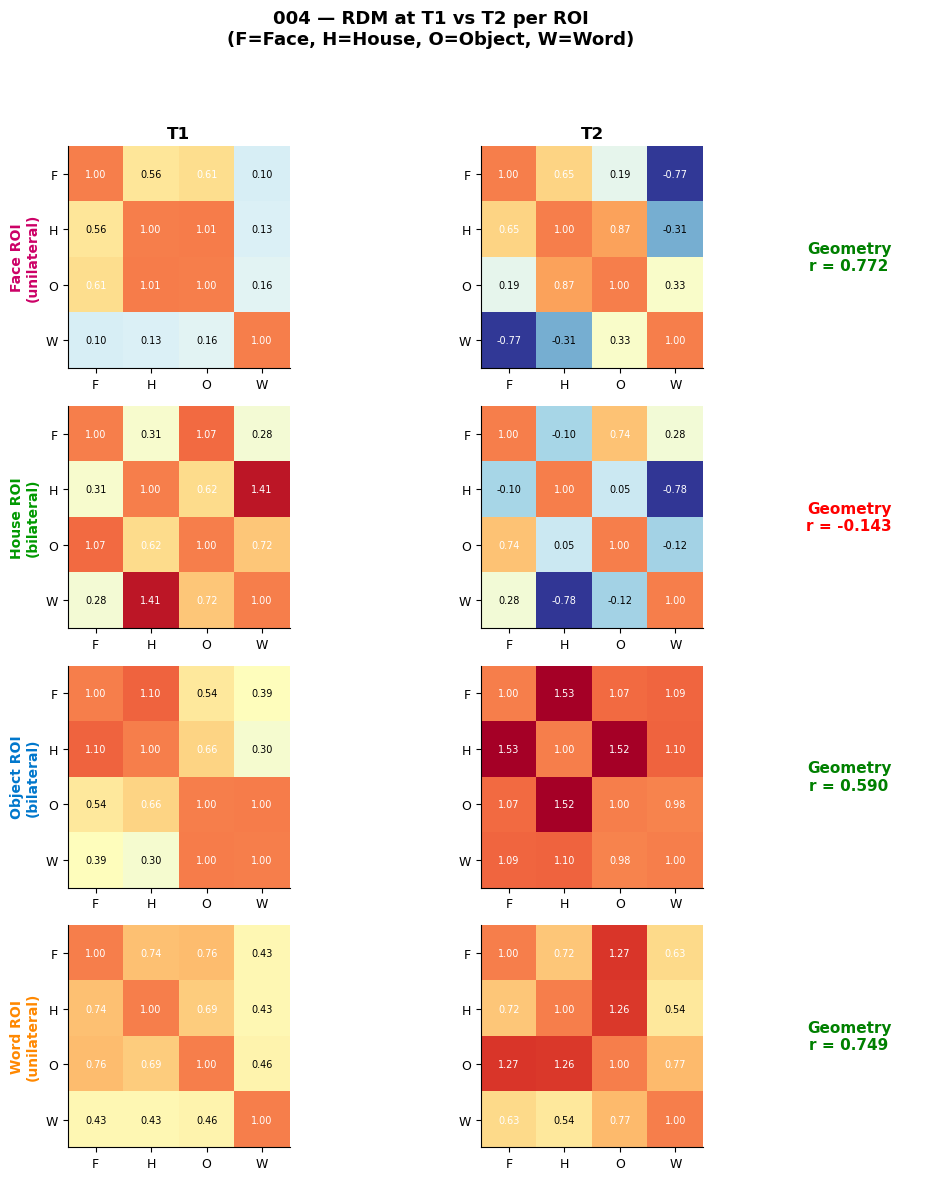

  Saved: fig_rdm_heatmap_OTC004_differential.png


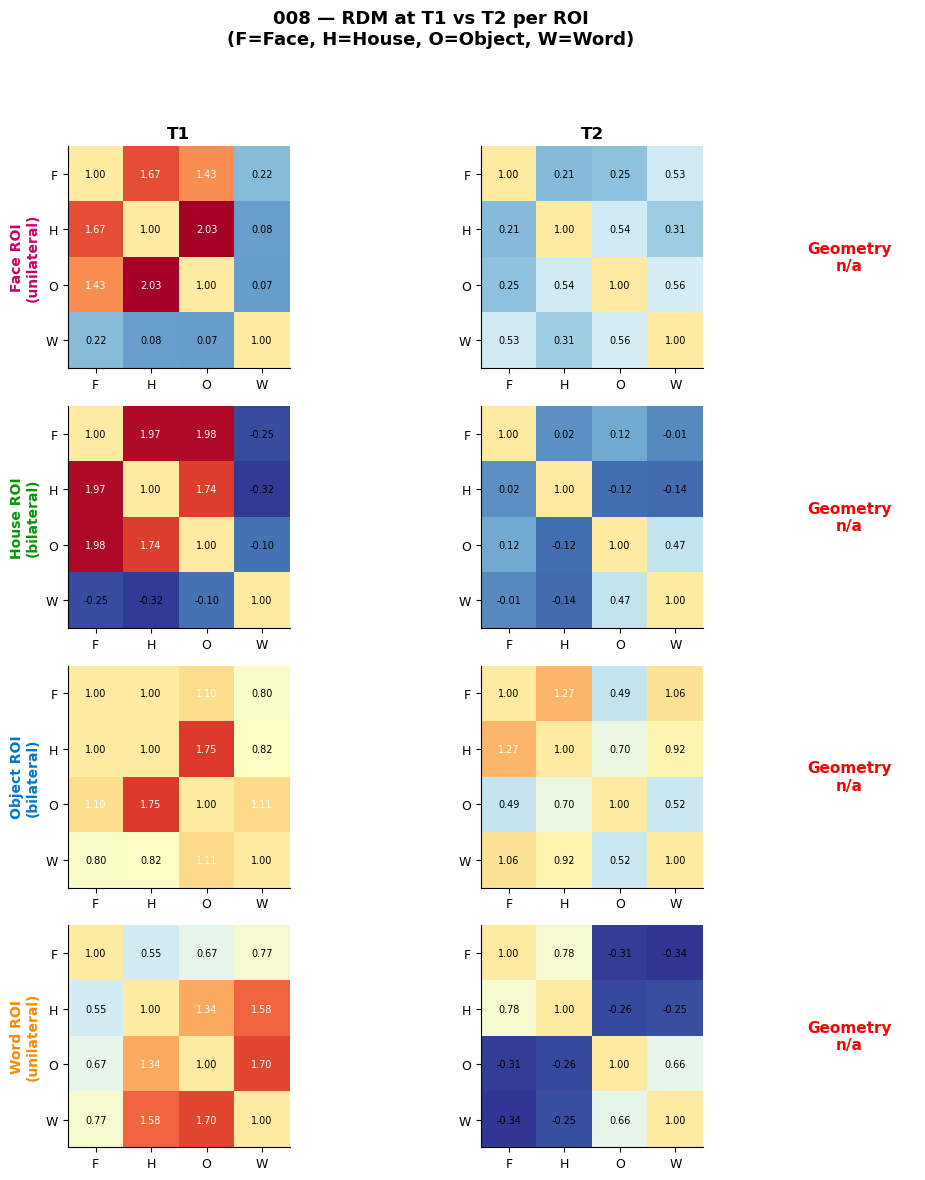

  Saved: fig_rdm_heatmap_OTC008_differential.png


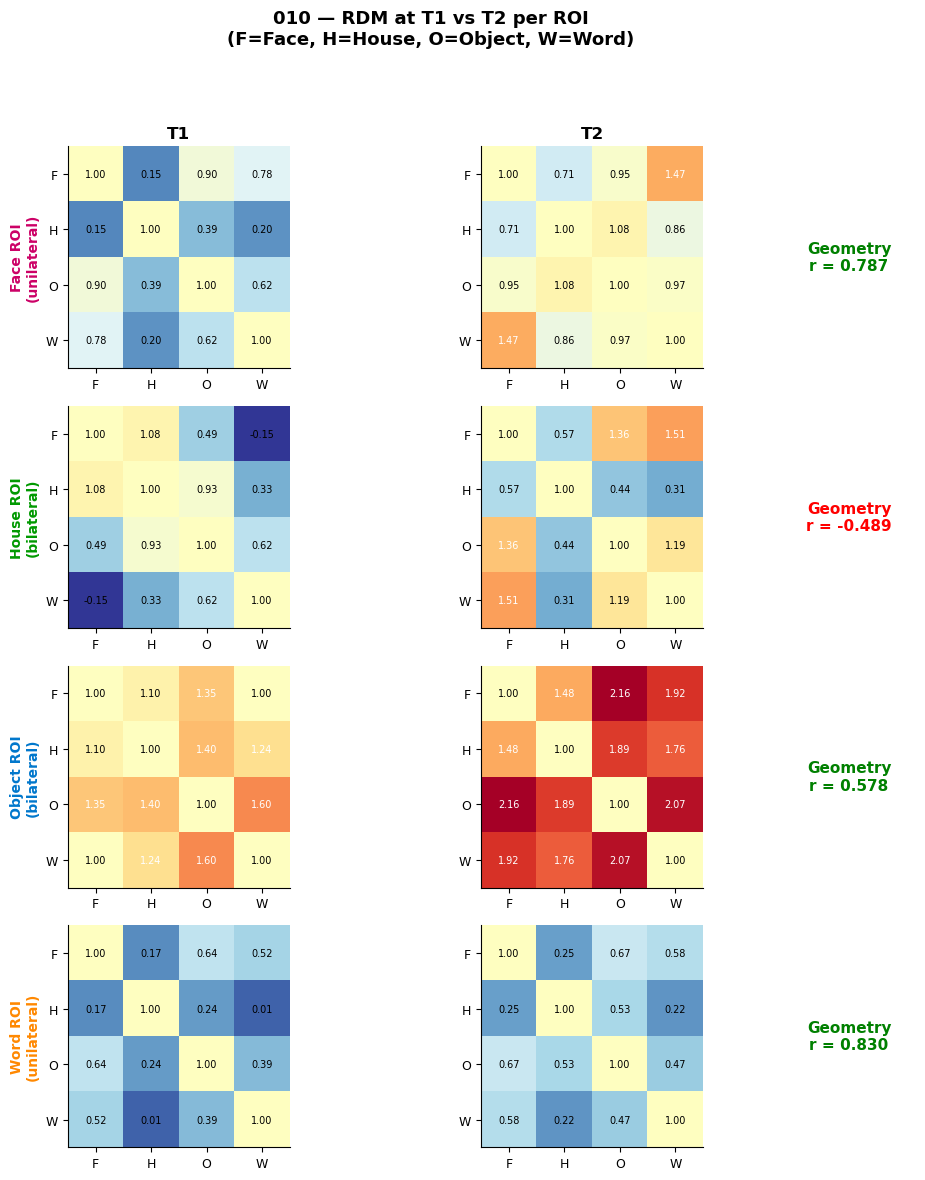

  Saved: fig_rdm_heatmap_OTC010_differential.png


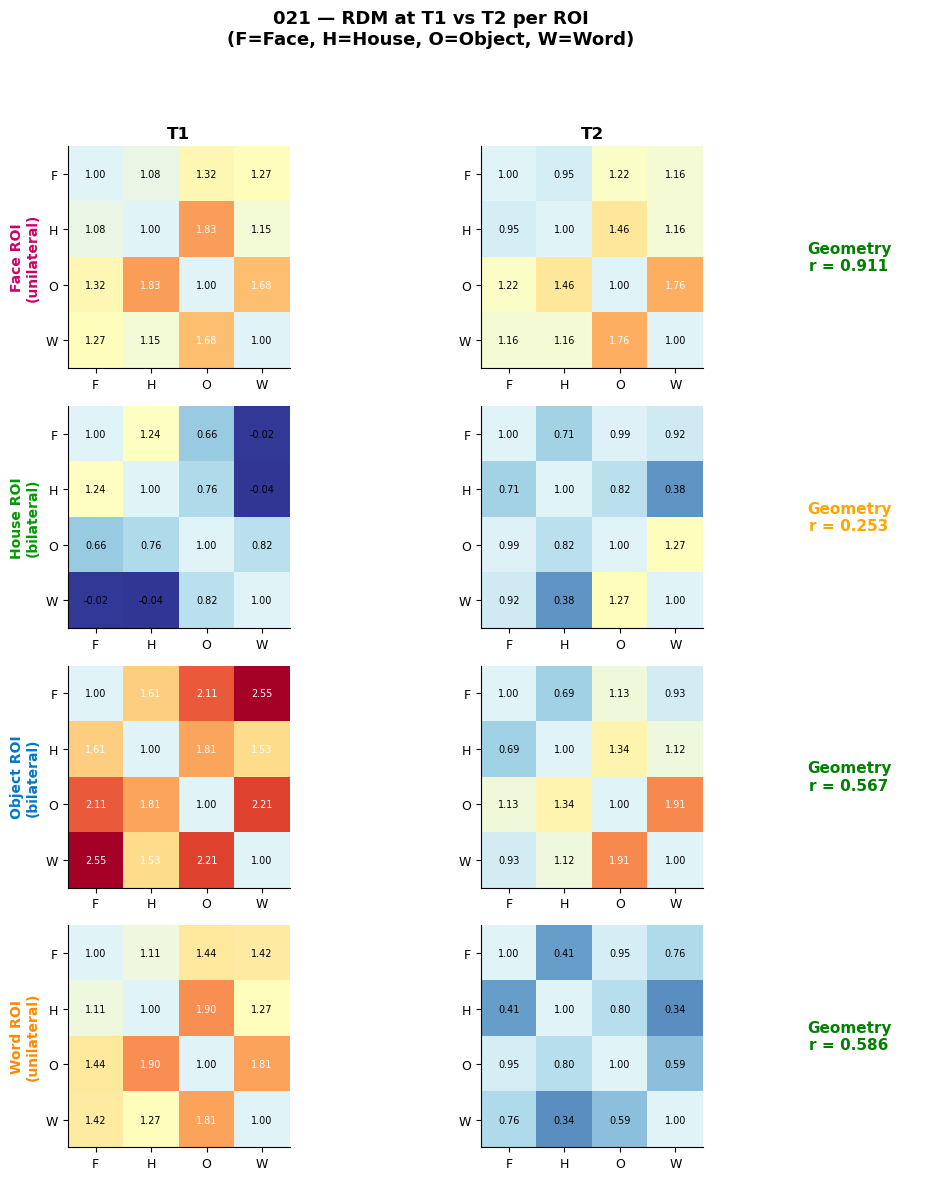

  Saved: fig_rdm_heatmap_OTC021_differential.png


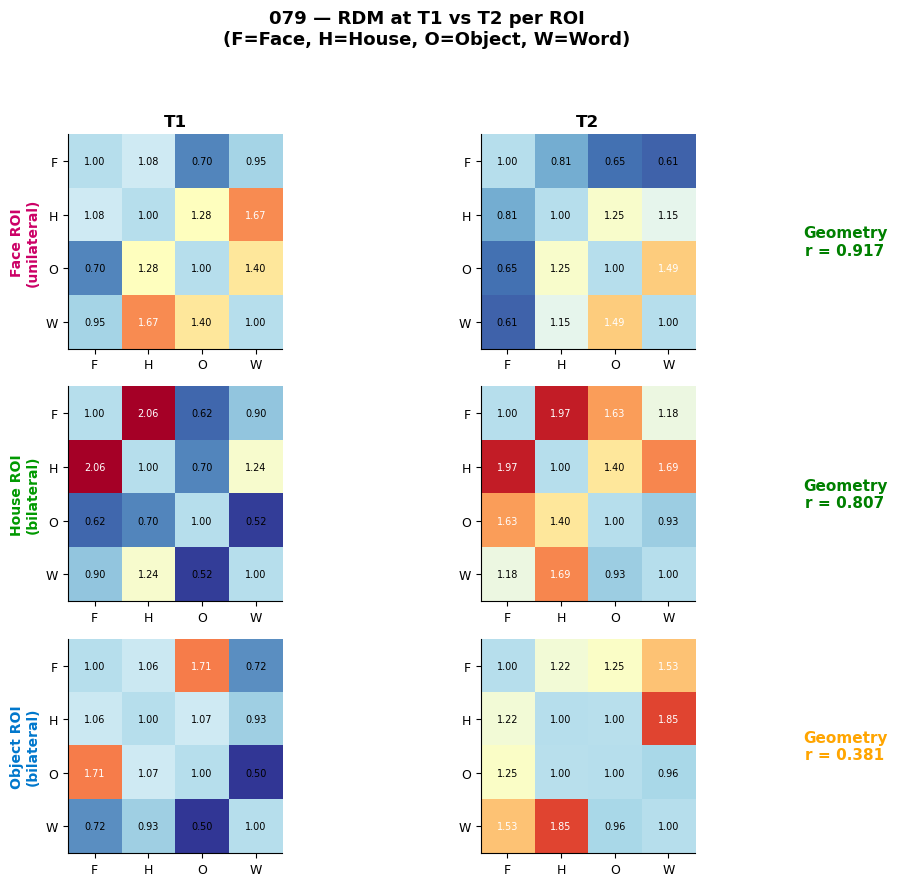

  Saved: fig_rdm_heatmap_OTC079_differential.png


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# RDM HEATMAPS: Visualize geometry preservation per ROI
# ═══════════════════════════════════════════════════════════════════════════════
# Show T1 vs T2 RDM side-by-side for each category ROI in selected patients.
# Face ROI should look stable (high geometry); House ROI should look different
# between T1 and T2 (low geometry).
#
# Uses the 6mm sphere pairwise data from 07_liu_distinctiveness.py
# ═══════════════════════════════════════════════════════════════════════════════

# Load sphere-based pairwise data (NOT searchmask)
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
pair_sphere_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
if not pair_sphere_file.exists():
    print(f'SKIP: {pair_sphere_file} not found')
else:
    df_pw = pd.read_csv(pair_sphere_file)
    df_pw = df_pw[df_pw['category'].isin(CATEGORIES)]
    df_pw = df_pw[~df_pw['subject_id'].isin(EXCLUDE)]
    df_pw = df_pw[~df_pw['subject'].str.contains('017')]

    # Identify longitudinal subjects
    ses_c = df_pw.groupby('subject_id')['session'].nunique()
    multi = ses_c[ses_c >= 2].index.tolist()
    df_pw_long = df_pw[df_pw['subject_id'].isin(multi)].copy()
    df_pw_long['ses_rank'] = df_pw_long.groupby('subject_id')['session'].rank(
        method='dense').astype(int)

    # Keep T1 and T2 (last session)
    max_rank = df_pw_long.groupby('subject_id')['ses_rank'].transform('max')
    df_pw_long = df_pw_long[(df_pw_long['ses_rank'] == 1) |
                             (df_pw_long['ses_rank'] == max_rank)].copy()
    df_pw_long['tp'] = df_pw_long['ses_rank'].apply(
        lambda x: 'T1' if x == 1 else 'T2')

    # Only patients, intact hemisphere
    otc_pw = df_pw_long[(df_pw_long['group'] == 'OTC') &
                         (df_pw_long['hemi_label'] == 'intact')]

    CAT_ORDER = ['face', 'house', 'object', 'word']
    PAIR_TO_IDX = {}
    for i, c1 in enumerate(CAT_ORDER):
        for j, c2 in enumerate(CAT_ORDER):
            if i < j:
                PAIR_TO_IDX[f'{c1}-{c2}'] = (i, j)

    def build_rdm(pair_df):
        """Reconstruct 4x4 Fisher-z correlation matrix from pairwise data."""
        mat = np.eye(4)  # diagonal = 1 (self-correlation)
        for _, row in pair_df.iterrows():
            pair = row['pair']
            if pair in PAIR_TO_IDX:
                i, j = PAIR_TO_IDX[pair]
                mat[i, j] = row['fisher_r']
                mat[j, i] = row['fisher_r']
        return mat

    # Select patients to plot
    plot_subs = sorted(otc_pw['subject_id'].unique())

    for sub in plot_subs:
        sub_df = otc_pw[otc_pw['subject_id'] == sub]
        sub_code = sub_df['subject'].iloc[0]

        # One figure per patient: rows = ROI categories, columns = T1, T2
        rois_with_data = []
        for roi_cat in CATEGORIES:
            t1_data = sub_df[(sub_df['category'] == roi_cat) &
                              (sub_df['tp'] == 'T1')]
            t2_data = sub_df[(sub_df['category'] == roi_cat) &
                              (sub_df['tp'] == 'T2')]
            if len(t1_data) >= 6 and len(t2_data) >= 6:
                rois_with_data.append(roi_cat)

        if not rois_with_data:
            continue

        n_rois = len(rois_with_data)
        fig, axes = plt.subplots(n_rois, 3, figsize=(10, 3 * n_rois),
                                  gridspec_kw={'width_ratios': [1, 1, 0.3]})
        if n_rois == 1:
            axes = axes.reshape(1, -1)

        # Get geometry values for this patient
        geo_sub = df_geo[(df_geo['subject_id'] == sub) &
                          (df_geo['hemi_label'] == 'intact') &
                          (~df_geo['subject'].str.contains('017|008'))]

        # Determine global color range across all RDMs for this patient
        all_vals = []
        for roi_cat in rois_with_data:
            for tp in ['T1', 'T2']:
                tp_data = sub_df[(sub_df['category'] == roi_cat) &
                                  (sub_df['tp'] == tp)]
                if len(tp_data) >= 6:
                    rdm = build_rdm(tp_data)
                    all_vals.extend(rdm[np.triu_indices(4, k=1)].tolist())
                    all_vals.extend(rdm[np.tril_indices(4, k=-1)].tolist())

        vmin = min(all_vals) if all_vals else -0.5
        vmax = max(all_vals) if all_vals else 1.5

        for row_idx, roi_cat in enumerate(rois_with_data):
            # Get geometry preservation value
            geo_val = geo_sub[geo_sub['category'] == roi_cat]['geometry_preservation']
            geo_str = f'r = {geo_val.values[0]:.3f}' if len(geo_val) > 0 else 'n/a'
            cat_type = 'bilateral' if roi_cat in BILATERAL else 'unilateral'

            for col_idx, tp in enumerate(['T1', 'T2']):
                ax = axes[row_idx, col_idx]
                tp_data = sub_df[(sub_df['category'] == roi_cat) &
                                  (sub_df['tp'] == tp)]

                if len(tp_data) >= 6:
                    rdm = build_rdm(tp_data)
                    im = ax.imshow(rdm, cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                                    aspect='equal')
                    ax.set_xticks(range(4))
                    ax.set_xticklabels([c[0].upper() for c in CAT_ORDER], fontsize=9)
                    ax.set_yticks(range(4))
                    ax.set_yticklabels([c[0].upper() for c in CAT_ORDER], fontsize=9)

                    # Add values in cells
                    for i in range(4):
                        for j in range(4):
                            color = 'white' if abs(rdm[i, j]) > (vmax - vmin) * 0.6 + vmin else 'black'
                            ax.text(j, i, f'{rdm[i,j]:.2f}', ha='center', va='center',
                                    fontsize=7, color=color)
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)
                    ax.set_xticks([])
                    ax.set_yticks([])

                if row_idx == 0:
                    ax.set_title(tp, fontsize=12, fontweight='bold')
                if col_idx == 0:
                    ax.set_ylabel(f'{roi_cat.title()} ROI\n({cat_type})',
                                   fontsize=10, fontweight='bold',
                                   color=CAT_COLORS[roi_cat])

            # Third column: geometry value
            ax_geo = axes[row_idx, 2]
            ax_geo.axis('off')
            geo_color = 'green' if len(geo_val) > 0 and geo_val.values[0] > 0.5 else \
                        'orange' if len(geo_val) > 0 and geo_val.values[0] > 0 else 'red'
            ax_geo.text(0.5, 0.5, f'Geometry\n{geo_str}',
                        ha='center', va='center', fontsize=11,
                        fontweight='bold', color=geo_color,
                        transform=ax_geo.transAxes)

        plt.suptitle(f'{short_name(sub_code)} — RDM at T1 vs T2 per ROI\n'
                     f'(F=Face, H=House, O=Object, W=Word)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.savefig(str(FIG_DIR / f'fig_rdm_heatmap_{sub_code}_{COPE_SET}.png'),
                    dpi=200, bbox_inches='tight')
        plt.show()
        print(f'  Saved: fig_rdm_heatmap_{sub_code}_{COPE_SET}.png')

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# RDM DISTANCE: How far did each ROI's representation actually move?
# ═══════════════════════════════════════════════════════════════════════════════
# Euclidean distance between T1 and T2 RDM vectors (6 pairwise values).
# This directly answers: which categories change more in representational space?
#
# Unlike geometry preservation (correlation = shape preserved?),
# this measures MAGNITUDE of change regardless of direction.
# ═══════════════════════════════════════════════════════════════════════════════

# Load pairwise sphere data
pair_file = BASE / 'group_results' / 'liu_distinctiveness' / f'pairwise_correlations_{COPE_SET}.csv'
df_pw = pd.read_csv(pair_file)
df_pw = df_pw[df_pw['category'].isin(CATEGORIES)]
df_pw = df_pw[~df_pw['subject_id'].isin(EXCLUDE)]
df_pw = df_pw[~df_pw['subject'].str.contains('017')]

# Longitudinal subjects only
ses_c = df_pw.groupby('subject_id')['session'].nunique()
multi = ses_c[ses_c >= 2].index.tolist()
df_pw_long = df_pw[df_pw['subject_id'].isin(multi)].copy()

# Rank sessions, keep first and last
df_pw_long['ses_rank'] = df_pw_long.groupby('subject_id')['session'].rank(
    method='dense').astype(int)
max_rank = df_pw_long.groupby('subject_id')['ses_rank'].transform('max')
df_pw_long = df_pw_long[(df_pw_long['ses_rank'] == 1) |
                         (df_pw_long['ses_rank'] == max_rank)].copy()
df_pw_long['tp'] = df_pw_long['ses_rank'].apply(lambda x: 'T1' if x == 1 else 'T2')

ALL_PAIRS = sorted(df_pw_long['pair'].unique())

def compute_rdm_distance(df, subject_id, roi_cat):
    """Euclidean distance between T1 and T2 RDM vectors for one subject × ROI."""
    sub_df = df[df['subject_id'] == subject_id]
    
    t1_vals = []
    t2_vals = []
    for pair in ALL_PAIRS:
        t1 = sub_df[(sub_df['category'] == roi_cat) & 
                     (sub_df['pair'] == pair) & 
                     (sub_df['tp'] == 'T1')]['fisher_r']
        t2 = sub_df[(sub_df['category'] == roi_cat) & 
                     (sub_df['pair'] == pair) & 
                     (sub_df['tp'] == 'T2')]['fisher_r']
        if len(t1) > 0 and len(t2) > 0:
            t1_vals.append(t1.values[0])
            t2_vals.append(t2.values[0])
    
    if len(t1_vals) < 6:
        return np.nan
    
    return np.sqrt(np.sum((np.array(t1_vals) - np.array(t2_vals))**2))

# Compute for all subjects × ROIs
rows = []

# OTC patients (intact hemi only)
otc_pw = df_pw_long[(df_pw_long['group'] == 'OTC') & 
                     (df_pw_long['hemi_label'] == 'intact')]
for sub in sorted(otc_pw['subject_id'].unique()):
    sub_code = otc_pw[otc_pw['subject_id'] == sub]['subject'].iloc[0]
    for roi_cat in CATEGORIES:
        d = compute_rdm_distance(otc_pw, sub, roi_cat)
        if np.isfinite(d):
            rows.append({
                'subject': sub_code, 'subject_id': sub,
                'group': 'OTC', 'status': 'patient',
                'category': roi_cat,
                'cat_type': 'bilateral' if roi_cat in BILATERAL else 'unilateral',
                'rdm_distance': d,
            })

# Controls (both hemispheres, will average)
ctrl_pw = df_pw_long[df_pw_long['status'] == 'control']
for sub in sorted(ctrl_pw['subject_id'].unique()):
    sub_code = ctrl_pw[ctrl_pw['subject_id'] == sub]['subject'].iloc[0]
    for roi_cat in CATEGORIES:
        # Compute per hemisphere then average
        dists = []
        for hl in ['left', 'right']:
            sub_hemi = ctrl_pw[(ctrl_pw['subject_id'] == sub) & 
                                (ctrl_pw['hemi_label'] == hl)]
            if len(sub_hemi) > 0:
                d = compute_rdm_distance(sub_hemi, sub, roi_cat)
                if np.isfinite(d):
                    dists.append(d)
        if dists:
            rows.append({
                'subject': sub_code, 'subject_id': sub,
                'group': 'control', 'status': 'control',
                'category': roi_cat,
                'cat_type': 'bilateral' if roi_cat in BILATERAL else 'unilateral',
                'rdm_distance': np.mean(dists),
            })

df_rdm_dist = pd.DataFrame(rows)

# ── Per category descriptives ─────────────────────────────────────────────
print('='*70)
print('RDM DISTANCE: Magnitude of representational change (T1 → T2)')
print('  Higher = more change in representational space')
print('='*70)

print(f'\n{"Category":<10} {"Type":<12} {"OTC M":>8} {"OTC SD":>8} {"Ctrl M":>8} {"Ctrl SD":>8}')
print('─'*58)
for cat in CATEGORIES:
    otc_v = df_rdm_dist[(df_rdm_dist['group'] == 'OTC') & 
                         (df_rdm_dist['category'] == cat)]['rdm_distance'].values
    ctrl_v = df_rdm_dist[(df_rdm_dist['group'] == 'control') & 
                          (df_rdm_dist['category'] == cat)]['rdm_distance'].values
    ct = 'bilateral' if cat in BILATERAL else 'unilateral'
    print(f'{cat:<10} {ct:<12} {np.nanmean(otc_v):>8.3f} {np.nanstd(otc_v):>8.3f} '
          f'{np.nanmean(ctrl_v):>8.3f} {np.nanstd(ctrl_v):>8.3f}')

# ── Per patient ───────────────────────────────────────────────────────────
print(f'\nPer patient (OTC):')
print(f'{"Subject":<12} {"Face":>8} {"Word":>8} {"House":>8} {"Object":>8} {"Bil M":>8} {"Uni M":>8} {"Diff":>8}')
print('─'*70)
for sub in sorted(df_rdm_dist[df_rdm_dist['group'] == 'OTC']['subject'].unique()):
    sd = df_rdm_dist[(df_rdm_dist['subject'] == sub)]
    vals = {}
    for cat in CATEGORIES:
        v = sd[sd['category'] == cat]['rdm_distance'].values
        vals[cat] = v[0] if len(v) > 0 else np.nan
    bil = np.nanmean([vals['house'], vals['object']])
    uni = np.nanmean([vals['face'], vals['word']])
    diff = bil - uni
    direction = '↑ bil' if diff > 0 else '↓ uni'
    print(f'{sub:<12} {vals["face"]:>8.3f} {vals["word"]:>8.3f} '
          f'{vals["house"]:>8.3f} {vals["object"]:>8.3f} '
          f'{bil:>8.3f} {uni:>8.3f} {diff:>+8.3f} {direction}')

# ── Bilateral vs Unilateral test ──────────────────────────────────────────
print(f'\n{"="*70}')
print('BILATERAL vs UNILATERAL RDM DISTANCE')
print('='*70)

# OTC
otc_dist = df_rdm_dist[df_rdm_dist['group'] == 'OTC']
bil_per_sub = []
uni_per_sub = []
for sub in otc_dist['subject'].unique():
    sd = otc_dist[otc_dist['subject'] == sub]
    b = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    u = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    if np.isfinite(b) and np.isfinite(u):
        bil_per_sub.append(b)
        uni_per_sub.append(u)

bil_arr = np.array(bil_per_sub)
uni_arr = np.array(uni_per_sub)
print(f'\nOTC (n={len(bil_arr)}):')
print(f'  Bilateral M  = {bil_arr.mean():.3f} (SD={bil_arr.std():.3f})')
print(f'  Unilateral M = {uni_arr.mean():.3f} (SD={uni_arr.std():.3f})')
print(f'  Diff (bil-uni) = {bil_arr.mean() - uni_arr.mean():+.3f}')
if len(bil_arr) >= 3:
    t, p = ttest_rel(bil_arr, uni_arr)
    d = (bil_arr - uni_arr).mean() / (bil_arr - uni_arr).std() if (bil_arr - uni_arr).std() > 0 else np.nan
    print(f'  Paired t({len(bil_arr)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

# Controls
ctrl_dist = df_rdm_dist[df_rdm_dist['group'] == 'control']
bil_c, uni_c = [], []
for sub in ctrl_dist['subject'].unique():
    sd = ctrl_dist[ctrl_dist['subject'] == sub]
    b = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    u = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    if np.isfinite(b) and np.isfinite(u):
        bil_c.append(b)
        uni_c.append(u)

bil_c_arr = np.array(bil_c)
uni_c_arr = np.array(uni_c)
print(f'\nControls (n={len(bil_c_arr)}):')
print(f'  Bilateral M  = {bil_c_arr.mean():.3f} (SD={bil_c_arr.std():.3f})')
print(f'  Unilateral M = {uni_c_arr.mean():.3f} (SD={uni_c_arr.std():.3f})')
print(f'  Diff (bil-uni) = {bil_c_arr.mean() - uni_c_arr.mean():+.3f}')
if len(bil_c_arr) >= 3:
    t_c, p_c = ttest_rel(bil_c_arr, uni_c_arr)
    print(f'  Paired t({len(bil_c_arr)-1})={t_c:.3f}, p={p_c:.4f}')

# Difference of differences
print(f'\nDifference-of-differences:')
otc_diffs = bil_arr - uni_arr
ctrl_diffs = bil_c_arr - uni_c_arr
rng_dd = np.random.default_rng(42)
boot_dd = np.empty(100000)
for i in range(100000):
    o = rng_dd.choice(otc_diffs, size=len(otc_diffs), replace=True)
    c = rng_dd.choice(ctrl_diffs, size=len(ctrl_diffs), replace=True)
    boot_dd[i] = o.mean() - c.mean()
dd_mean = otc_diffs.mean() - ctrl_diffs.mean()
dd_ci = np.percentile(boot_dd, [2.5, 97.5])
sig = 'SIGNIFICANT' if dd_ci[0] > 0 or dd_ci[1] < 0 else 'not significant'
print(f'  OTC diff:     {otc_diffs.mean():+.3f}')
print(f'  Control diff: {ctrl_diffs.mean():+.3f}')
print(f'  Diff-of-diff: {dd_mean:+.3f}  95% CI [{dd_ci[0]:+.3f}, {dd_ci[1]:+.3f}]')
print(f'  → {sig}')

RDM DISTANCE: Magnitude of representational change (T1 → T2)
  Higher = more change in representational space

Category   Type            OTC M   OTC SD   Ctrl M  Ctrl SD
──────────────────────────────────────────────────────────
face       unilateral      1.208    0.710    1.141    0.423
house      bilateral       2.116    0.752    1.730    0.785
object     bilateral       1.616    0.302    1.201    0.681
word       unilateral      1.611    1.051    1.255    0.566

Per patient (OTC):
Subject          Face     Word    House   Object    Bil M    Uni M     Diff
──────────────────────────────────────────────────────────────────────
OTC004          1.088    0.855    2.474    1.527    2.000    0.971   +1.029 ↑ bil
OTC008          2.478    3.031    3.334    1.407    2.371    2.754   -0.384 ↓ uni
OTC010          1.351    0.382    2.089    1.547    1.818    0.867   +0.951 ↑ bil
OTC021          0.435    2.175    1.283    2.207    1.745    1.305   +0.440 ↑ bil
OTC079          0.686      nan    1

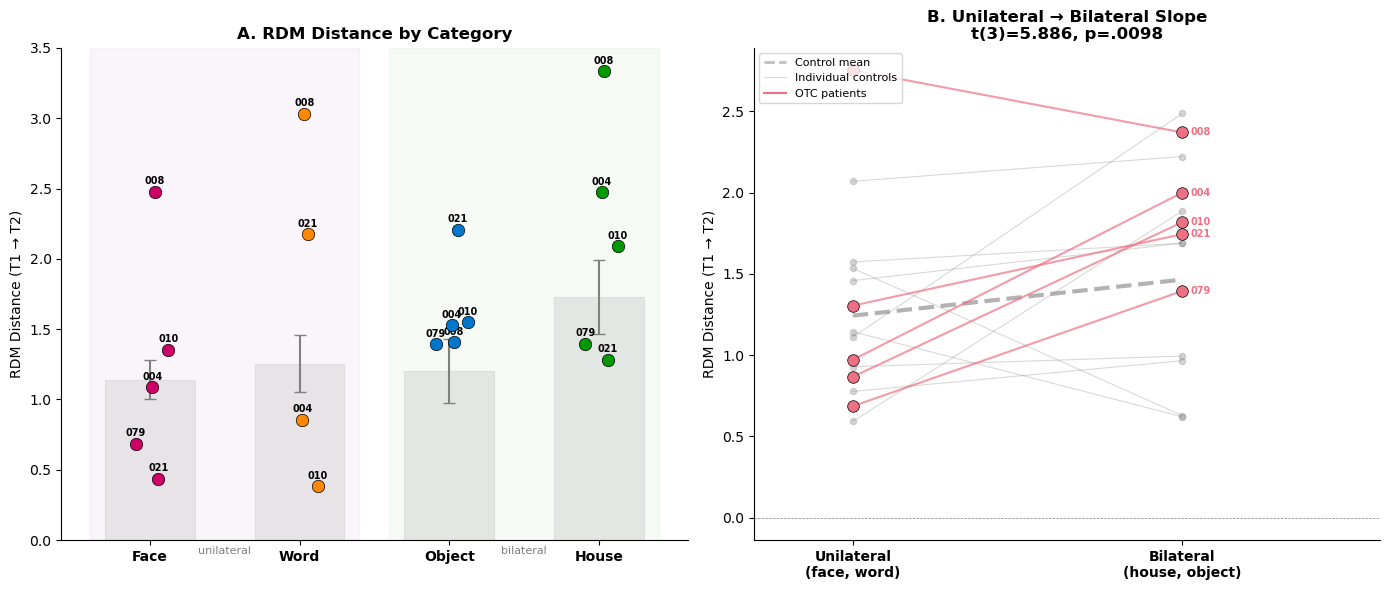

WITHIN-PATIENT CATEGORY COMPARISONS (paired t-tests, OTC)
  Each pair: is category A RDM distance ≠ category B?
  face     vs house   : n=5, M_diff=-0.908, t(4)=-7.380, p=0.0018 *
  face     vs object  : n=5, M_diff=-0.409, t(4)=-0.894, p=0.4220 
  face     vs word    : n=4, M_diff=-0.273, t(3)=-0.471, p=0.6698 
  house    vs object  : n=5, M_diff=+0.499, t(4)=1.051, p=0.3524 
  house    vs word    : n=4, M_diff=+0.684, t(3)=1.111, p=0.3475 
  object   vs word    : n=4, M_diff=+0.061, t(3)=0.101, p=0.9260 

PER-CATEGORY OTC vs CONTROLS:
Category      OTC M   Ctrl M     Diff        t        p
────────────────────────────────────────────────────
face          1.208    1.141   +0.066    0.202   0.8432 
house         2.116    1.730   +0.386    0.828   0.4240 
object        1.616    1.201   +0.416    1.199   0.2536 
word          1.611    1.255   +0.356    0.696   0.5023 


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# RDM DISTANCE: Visualization + Within-Patient Category Comparisons
# ═══════════════════════════════════════════════════════════════════════════════

BILATERAL = ['house', 'object']
UNILATERAL = ['face', 'word']
CAT_COLORS = {'face': '#cc0066', 'word': '#ff8800', 'house': '#009900', 'object': '#0077cc'}

# ── Figure 1: Slope plot (like geometry) — unilateral to bilateral per patient ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: individual categories
otc_dist = df_rdm_dist[df_rdm_dist['group'] == 'OTC']
ctrl_dist = df_rdm_dist[df_rdm_dist['group'] == 'control']

cat_order = ['face', 'word', 'object', 'house']
cat_x = {cat: i for i, cat in enumerate(cat_order)}

# Control means + SD as background
for cat in cat_order:
    cv = ctrl_dist[ctrl_dist['category'] == cat]['rdm_distance'].values
    if len(cv) > 0:
        ax1.bar(cat_x[cat], np.mean(cv), width=0.6, alpha=0.15,
                color='gray', edgecolor='gray', linewidth=0.8)
        ax1.errorbar(cat_x[cat], np.mean(cv), yerr=np.std(cv)/np.sqrt(len(cv)),
                     color='gray', capsize=4, linewidth=1.5, zorder=2)

# OTC individual patients
OTC_L_COLOR = '#7398af'
OTC_R_COLOR = '#ee7183'

for sub in sorted(otc_dist['subject'].unique()):
    sd = otc_dist[otc_dist['subject'] == sub]
    surgery = sd['status'].iloc[0]  # need surgery side
    
    for cat in cat_order:
        v = sd[sd['category'] == cat]['rdm_distance'].values
        if len(v) > 0:
            jit = np.random.default_rng(hash(sub) % 2**32).uniform(-0.15, 0.15)
            color = CAT_COLORS[cat]
            ax1.scatter(cat_x[cat] + jit, v[0], color=color, s=80, zorder=4,
                       edgecolors='black', linewidth=0.5)
            label = sub.replace('OTC', '').replace('nonOTC', 'n').replace('control', 'c')
            ax1.annotate(label, (cat_x[cat] + jit, v[0]),
                        fontsize=7, fontweight='bold', ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points')

# Shading
ax1.axvspan(-0.4, 1.4, alpha=0.04, color='purple', zorder=0)
ax1.axvspan(1.6, 3.4, alpha=0.04, color='green', zorder=0)
ax1.text(0.5, ax1.get_ylim()[0] - 0.1, 'unilateral', ha='center', fontsize=8, color='gray')
ax1.text(2.5, ax1.get_ylim()[0] - 0.1, 'bilateral', ha='center', fontsize=8, color='gray')

ax1.set_xticks(range(4))
ax1.set_xticklabels([c.title() for c in cat_order], fontsize=10, fontweight='bold')
ax1.set_ylabel('RDM Distance (T1 → T2)', fontsize=10)
ax1.set_title('A. RDM Distance by Category', fontsize=12, fontweight='bold')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Right panel: slope plot — unilateral mean → bilateral mean
# Controls in gray background
for sub in ctrl_dist['subject'].unique():
    sd = ctrl_dist[ctrl_dist['subject'] == sub]
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    if np.isfinite(uni) and np.isfinite(bil):
        ax2.plot([0, 1], [uni, bil], color='gray', linewidth=0.8, alpha=0.3, zorder=1)
        ax2.scatter([0, 1], [uni, bil], color='gray', s=20, alpha=0.3, zorder=1)

# Control group mean
ctrl_uni_m = ctrl_dist[ctrl_dist['cat_type'] == 'unilateral'].groupby('subject')['rdm_distance'].mean().mean()
ctrl_bil_m = ctrl_dist[ctrl_dist['cat_type'] == 'bilateral'].groupby('subject')['rdm_distance'].mean().mean()
ax2.plot([0, 1], [ctrl_uni_m, ctrl_bil_m], color='gray', linewidth=3, alpha=0.6,
         linestyle='--', zorder=2)

# OTC patients
for sub in sorted(otc_dist['subject'].unique()):
    sd = otc_dist[otc_dist['subject'] == sub]
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    if not (np.isfinite(uni) and np.isfinite(bil)):
        continue
    
    col = OTC_R_COLOR  # default; adjust if you have surgery_side in df
    label = sub.replace('OTC', '').replace('nonOTC', 'n')
    
    ax2.plot([0, 1], [uni, bil], color=col, linewidth=1.5, alpha=0.7, zorder=3)
    ax2.scatter(0, uni, color=col, s=70, zorder=4, edgecolors='black', linewidth=0.5)
    ax2.scatter(1, bil, color=col, s=70, zorder=4, edgecolors='black', linewidth=0.5)
    ax2.annotate(label, (1, bil), fontsize=7, fontweight='bold', ha='left',
                va='center', xytext=(6, 0), textcoords='offset points', color=col)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Unilateral\n(face, word)', 'Bilateral\n(house, object)'],
                     fontsize=10, fontweight='bold')
ax2.set_ylabel('RDM Distance (T1 → T2)', fontsize=10)
ax2.set_title('B. Unilateral → Bilateral Slope\nt(3)=5.886, p=.0098', fontsize=12, fontweight='bold')
ax2.set_xlim(-0.3, 1.6)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax2.legend(handles=[
    Line2D([0], [0], color='gray', linewidth=2, alpha=0.5, linestyle='--', label='Control mean'),
    Line2D([0], [0], color='gray', linewidth=0.8, alpha=0.3, label='Individual controls'),
    Line2D([0], [0], color=OTC_R_COLOR, linewidth=1.5, label='OTC patients'),
], loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(str(FIG_DIR / f'fig_rdm_distance_{COPE_SET}.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Within-patient category-level paired comparisons ──────────────────────
print('='*70)
print('WITHIN-PATIENT CATEGORY COMPARISONS (paired t-tests, OTC)')
print('  Each pair: is category A RDM distance ≠ category B?')
print('='*70)

from itertools import combinations

for cat_a, cat_b in combinations(CATEGORIES, 2):
    vals_a, vals_b = [], []
    for sub in otc_dist['subject'].unique():
        sd = otc_dist[otc_dist['subject'] == sub]
        va = sd[sd['category'] == cat_a]['rdm_distance'].values
        vb = sd[sd['category'] == cat_b]['rdm_distance'].values
        if len(va) > 0 and len(vb) > 0:
            vals_a.append(va[0])
            vals_b.append(vb[0])
    
    n = len(vals_a)
    if n >= 3:
        t, p = ttest_rel(vals_a, vals_b)
        mean_diff = np.mean(vals_a) - np.mean(vals_b)
        sig = '*' if p < .05 else ''
        print(f'  {cat_a:<8} vs {cat_b:<8}: n={n}, '
              f'M_diff={mean_diff:+.3f}, t({n-1})={t:.3f}, p={p:.4f} {sig}')
    else:
        print(f'  {cat_a:<8} vs {cat_b:<8}: n={n} — too few')

# ── Per-category OTC vs Controls ──────────────────────────────────────────
print(f'\nPER-CATEGORY OTC vs CONTROLS:')
print(f'{"Category":<10} {"OTC M":>8} {"Ctrl M":>8} {"Diff":>8} {"t":>8} {"p":>8}')
print('─'*52)
for cat in CATEGORIES:
    otc_v = otc_dist[otc_dist['category'] == cat]['rdm_distance'].values
    ctrl_v = ctrl_dist[ctrl_dist['category'] == cat]['rdm_distance'].values
    if len(otc_v) >= 2 and len(ctrl_v) >= 2:
        t, p = ttest_ind(otc_v, ctrl_v)
        diff = np.mean(otc_v) - np.mean(ctrl_v)
        sig = '*' if p < .05 else ''
        print(f'{cat:<10} {np.mean(otc_v):>8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{diff:>+8.3f} {t:>8.3f} {p:>8.4f} {sig}')

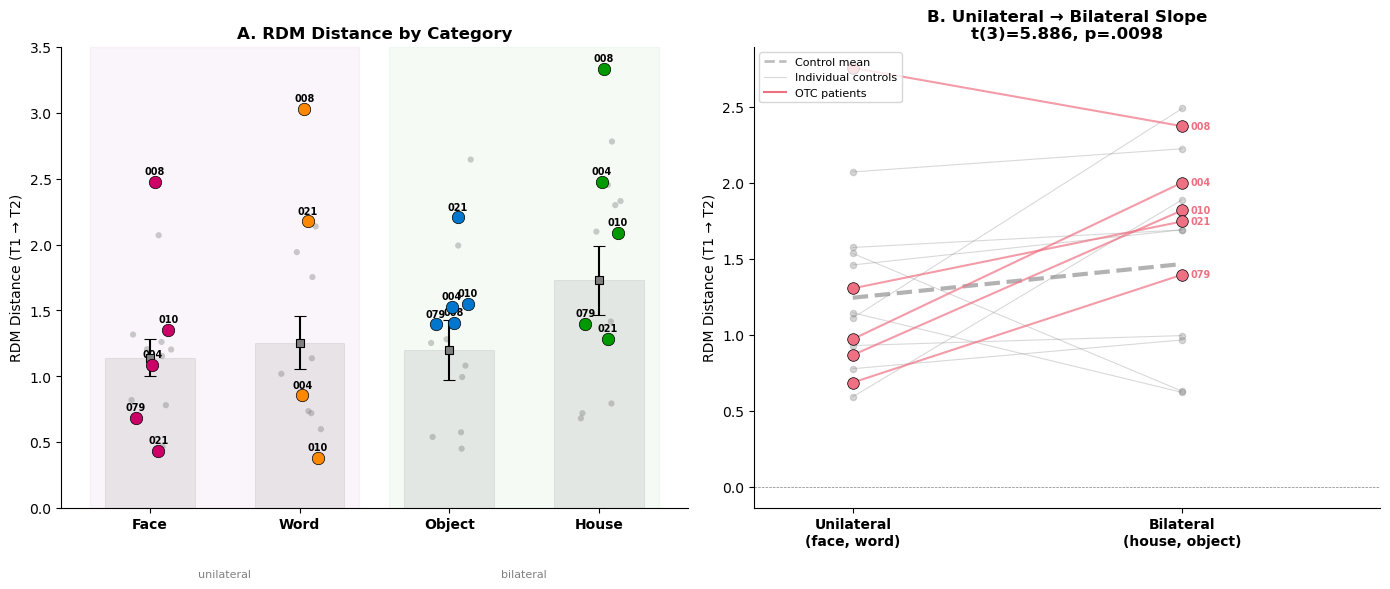

WITHIN-PATIENT CATEGORY COMPARISONS (paired t-tests, OTC)
  Each pair: is category A RDM distance ≠ category B?
  face     vs house   : n=5, M_diff=-0.908, t(4)=-7.380, p=0.0018 *
  face     vs object  : n=5, M_diff=-0.409, t(4)=-0.894, p=0.4220 
  face     vs word    : n=4, M_diff=-0.273, t(3)=-0.471, p=0.6698 
  house    vs object  : n=5, M_diff=+0.499, t(4)=1.051, p=0.3524 
  house    vs word    : n=4, M_diff=+0.684, t(3)=1.111, p=0.3475 
  object   vs word    : n=4, M_diff=+0.061, t(3)=0.101, p=0.9260 

PER-CATEGORY OTC vs CONTROLS:
Category      OTC M   Ctrl M     Diff        t        p
────────────────────────────────────────────────────
face          1.208    1.141   +0.066    0.202   0.8432 
house         2.116    1.730   +0.386    0.828   0.4240 
object        1.616    1.201   +0.416    1.199   0.2536 
word          1.611    1.255   +0.356    0.696   0.5023 


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# RDM DISTANCE: Visualization + Within-Patient Category Comparisons
# ═══════════════════════════════════════════════════════════════════════════════

BILATERAL = ['house', 'object']
UNILATERAL = ['face', 'word']
CAT_COLORS = {'face': '#cc0066', 'word': '#ff8800', 'house': '#009900', 'object': '#0077cc'}
OTC_L_COLOR = '#7398af'
OTC_R_COLOR = '#ee7183'

otc_dist = df_rdm_dist[df_rdm_dist['group'] == 'OTC']
ctrl_dist = df_rdm_dist[df_rdm_dist['group'] == 'control']

cat_order = ['face', 'word', 'object', 'house']
cat_x = {cat: i for i, cat in enumerate(cat_order)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Left panel: individual categories ─────────────────────────────────────

# Control individual dots + mean/SE
# Control bars + individual dots + mean/SE
for cat in cat_order:
    cv = ctrl_dist[ctrl_dist['category'] == cat]['rdm_distance'].values
    if len(cv) > 0:
        # Bar
        ax1.bar(cat_x[cat], np.mean(cv), width=0.6, alpha=0.15,
                color='gray', edgecolor='gray', linewidth=0.8, zorder=1)
        # Individual dots
        jit = np.random.default_rng(42).uniform(-0.15, 0.15, len(cv))
        ax1.scatter(np.full(len(cv), cat_x[cat]) + jit, cv,
                    color='gray', alpha=0.4, s=20, zorder=2, edgecolors='none')
        # Mean + SE
        ax1.errorbar(cat_x[cat], np.mean(cv), yerr=np.std(cv)/np.sqrt(len(cv)),
                     color='black', marker='s', markersize=6,
                     markerfacecolor='gray', markeredgecolor='black',
                     markeredgewidth=0.8, capsize=4, linewidth=1.5, zorder=3)

# OTC individual patients
for sub in sorted(otc_dist['subject'].unique()):
    sd = otc_dist[otc_dist['subject'] == sub]
    for cat in cat_order:
        v = sd[sd['category'] == cat]['rdm_distance'].values
        if len(v) > 0:
            jit = np.random.default_rng(hash(sub) % 2**32).uniform(-0.15, 0.15)
            ax1.scatter(cat_x[cat] + jit, v[0], color=CAT_COLORS[cat], s=80, zorder=4,
                        edgecolors='black', linewidth=0.5)
            label = sub.replace('OTC', '').replace('nonOTC', 'n').replace('control', 'c')
            ax1.annotate(label, (cat_x[cat] + jit, v[0]),
                         fontsize=7, fontweight='bold', ha='center', va='bottom',
                         xytext=(0, 4), textcoords='offset points')

# Shading
ax1.axvspan(-0.4, 1.4, alpha=0.04, color='purple', zorder=0)
ax1.axvspan(1.6, 3.4, alpha=0.04, color='green', zorder=0)
ax1.text(0.5, -0.15, 'unilateral', ha='center', fontsize=8, color='gray',
         transform=ax1.get_xaxis_transform())
ax1.text(2.5, -0.15, 'bilateral', ha='center', fontsize=8, color='gray',
         transform=ax1.get_xaxis_transform())

ax1.set_xticks(range(4))
ax1.set_xticklabels([c.title() for c in cat_order], fontsize=10, fontweight='bold')
ax1.set_ylabel('RDM Distance (T1 → T2)', fontsize=10)
ax1.set_title('A. RDM Distance by Category', fontsize=12, fontweight='bold')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Right panel: slope plot ───────────────────────────────────────────────

# Individual controls in gray
for sub in ctrl_dist['subject'].unique():
    sd = ctrl_dist[ctrl_dist['subject'] == sub]
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    if np.isfinite(uni) and np.isfinite(bil):
        ax2.plot([0, 1], [uni, bil], color='gray', linewidth=0.8, alpha=0.3, zorder=1)
        ax2.scatter([0, 1], [uni, bil], color='gray', s=20, alpha=0.3, zorder=1)

# Control group mean
ctrl_uni_m = ctrl_dist[ctrl_dist['cat_type'] == 'unilateral'].groupby('subject')['rdm_distance'].mean().mean()
ctrl_bil_m = ctrl_dist[ctrl_dist['cat_type'] == 'bilateral'].groupby('subject')['rdm_distance'].mean().mean()
ax2.plot([0, 1], [ctrl_uni_m, ctrl_bil_m], color='gray', linewidth=3, alpha=0.6,
         linestyle='--', zorder=2)

# OTC patients
for sub in sorted(otc_dist['subject'].unique()):
    sd = otc_dist[otc_dist['subject'] == sub]
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    if not (np.isfinite(uni) and np.isfinite(bil)):
        continue

    col = OTC_R_COLOR
    label = sub.replace('OTC', '').replace('nonOTC', 'n')

    ax2.plot([0, 1], [uni, bil], color=col, linewidth=1.5, alpha=0.7, zorder=3)
    ax2.scatter(0, uni, color=col, s=70, zorder=4, edgecolors='black', linewidth=0.5)
    ax2.scatter(1, bil, color=col, s=70, zorder=4, edgecolors='black', linewidth=0.5)
    ax2.annotate(label, (1, bil), fontsize=7, fontweight='bold', ha='left',
                 va='center', xytext=(6, 0), textcoords='offset points', color=col)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Unilateral\n(face, word)', 'Bilateral\n(house, object)'],
                     fontsize=10, fontweight='bold')
ax2.set_ylabel('RDM Distance (T1 → T2)', fontsize=10)
ax2.set_title('B. Unilateral → Bilateral Slope\nt(3)=5.886, p=.0098', fontsize=12, fontweight='bold')
ax2.set_xlim(-0.3, 1.6)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax2.legend(handles=[
    Line2D([0], [0], color='gray', linewidth=2, alpha=0.5, linestyle='--', label='Control mean'),
    Line2D([0], [0], color='gray', linewidth=0.8, alpha=0.3, label='Individual controls'),
    Line2D([0], [0], color=OTC_R_COLOR, linewidth=1.5, label='OTC patients'),
], loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(str(FIG_DIR / f'fig_rdm_distance_{COPE_SET}.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Within-patient category-level paired comparisons ──────────────────────
print('='*70)
print('WITHIN-PATIENT CATEGORY COMPARISONS (paired t-tests, OTC)')
print('  Each pair: is category A RDM distance ≠ category B?')
print('='*70)

from itertools import combinations

for cat_a, cat_b in combinations(CATEGORIES, 2):
    vals_a, vals_b = [], []
    for sub in otc_dist['subject'].unique():
        sd = otc_dist[otc_dist['subject'] == sub]
        va = sd[sd['category'] == cat_a]['rdm_distance'].values
        vb = sd[sd['category'] == cat_b]['rdm_distance'].values
        if len(va) > 0 and len(vb) > 0:
            vals_a.append(va[0])
            vals_b.append(vb[0])

    n = len(vals_a)
    if n >= 3:
        t, p = ttest_rel(vals_a, vals_b)
        mean_diff = np.mean(vals_a) - np.mean(vals_b)
        sig = '*' if p < .05 else ''
        print(f'  {cat_a:<8} vs {cat_b:<8}: n={n}, '
              f'M_diff={mean_diff:+.3f}, t({n-1})={t:.3f}, p={p:.4f} {sig}')
    else:
        print(f'  {cat_a:<8} vs {cat_b:<8}: n={n} — too few')

# ── Per-category OTC vs Controls ──────────────────────────────────────────
print(f'\nPER-CATEGORY OTC vs CONTROLS:')
print(f'{"Category":<10} {"OTC M":>8} {"Ctrl M":>8} {"Diff":>8} {"t":>8} {"p":>8}')
print('─'*52)
for cat in CATEGORIES:
    otc_v = otc_dist[otc_dist['category'] == cat]['rdm_distance'].values
    ctrl_v = ctrl_dist[ctrl_dist['category'] == cat]['rdm_distance'].values
    if len(otc_v) >= 2 and len(ctrl_v) >= 2:
        t, p = ttest_ind(otc_v, ctrl_v)
        diff = np.mean(otc_v) - np.mean(ctrl_v)
        sig = '*' if p < .05 else ''
        print(f'{cat:<10} {np.mean(otc_v):>8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{diff:>+8.3f} {t:>8.3f} {p:>8.4f} {sig}')

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# Is the bilateral-unilateral gap driven by crowding, age, or time?
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import spearmanr, pearsonr
import sys
sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, _load_csv

# ── Load subject info ─────────────────────────────────────────────────────
sub_info = _load_csv()
print(sub_info.columns.tolist())
print(sub_info.head())

# ── Compute per-patient bilateral-unilateral RDM distance gap ─────────────
otc_dist = df_rdm_dist[df_rdm_dist['group'] == 'OTC']
patient_gaps = {}
for sub in otc_dist['subject'].unique():
    sd = otc_dist[otc_dist['subject'] == sub]
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    sub_id = sd['subject_id'].iloc[0]
    patient_gaps[sub] = {'subject_id': sub_id, 'gap': bil - uni}

# ── Get face-word crowding from searchmask data ──────────────────────────
sm_file = BASE / 'group_results' / 'liu_distinctiveness' / f'pairwise_searchmask_{COPE_SET}.csv'
if sm_file.exists():
    df_sm = pd.read_csv(sm_file)
    df_sm = df_sm[~df_sm['subject'].str.contains('017|008')]
    
    # Longitudinal only
    ses_c = df_sm.groupby('subject_id')['session'].nunique()
    multi = ses_c[ses_c >= 2].index.tolist()
    df_sm_l = df_sm[df_sm['subject_id'].isin(multi)].copy()
    df_sm_l['ses_rank'] = df_sm_l.groupby('subject_id')['session'].rank(method='dense').astype(int)
    max_r = df_sm_l.groupby('subject_id')['ses_rank'].transform('max')
    df_sm_l = df_sm_l[(df_sm_l['ses_rank'] == 1) | (df_sm_l['ses_rank'] == max_r)].copy()
    df_sm_l['tp'] = df_sm_l['ses_rank'].apply(lambda x: 'T1' if x == 1 else 'T2')
    
    otc_sm = df_sm_l[(df_sm_l['group'] == 'OTC') & (df_sm_l['hemi_label'] == 'intact')]
    
    crowding = {}
    for sub_id in otc_sm['subject_id'].unique():
        sd = otc_sm[otc_sm['subject_id'] == sub_id]
        # face-word change in face searchmask
        t1 = sd[(sd['searchmask'] == 'face') & (sd['pair'] == 'face-word') & (sd['tp'] == 'T1')]['fisher_r']
        t2 = sd[(sd['searchmask'] == 'face') & (sd['pair'] == 'face-word') & (sd['tp'] == 'T2')]['fisher_r']
        if len(t1) > 0 and len(t2) > 0:
            crowding[sub_id] = t2.values[0] - t1.values[0]  # negative = more differentiated = crowding

# ── Build combined table ──────────────────────────────────────────────────
rows = []
for sub, data in patient_gaps.items():
    sub_id = data['subject_id']
    sub_clean = sub_id.replace('sub-', '')
    
    # Age
    sub_row = sub_info[sub_info['sub_clean'].astype(str) == sub_clean]
    age = None
    for col in sub_row.columns:
        if 'age' in col.lower():
            val = sub_row[col].values
            if len(val) > 0 and pd.notna(val[0]):
                age = float(val[0])
                break
    
    # Inter-session interval (from geometry CSV)
    geo_sub = df_geo[(df_geo['subject_id'] == sub_id) & 
                      (df_geo['hemi_label'] == 'intact') &
                      (~df_geo['subject'].str.contains('017|008'))]
    s1 = geo_sub['session_1'].iloc[0] if len(geo_sub) > 0 else None
    s2 = geo_sub['session_2'].iloc[0] if len(geo_sub) > 0 else None
    
    # Crowding
    crowd_val = crowding.get(sub_id, np.nan) if 'crowding' in dir() else np.nan
    
    rows.append({
        'subject': sub, 'subject_id': sub_id,
        'gap': data['gap'],
        'crowding': crowd_val,
        'age': age,
        'session_1': s1, 'session_2': s2,
    })

df_check = pd.DataFrame(rows)
print('\n' + '='*70)
print('PATIENT DATA')
print('='*70)
print(df_check.to_string(index=False))

# ── Correlations ──────────────────────────────────────────────────────────
print('\n' + '='*70)
print('CORRELATIONS WITH BILATERAL-UNILATERAL GAP')
print('='*70)

# Gap vs crowding
valid = df_check[['gap', 'crowding']].dropna()
if len(valid) >= 3:
    rho, p = spearmanr(valid['gap'], valid['crowding'])
    print(f'\n  Gap vs Crowding (face-word Δ): rho={rho:.3f}, p={p:.4f}, n={len(valid)}')
    print(f'    (negative crowding = more differentiation = more crowding)')
    for _, r in df_check.iterrows():
        print(f'    {r["subject"]}: gap={r["gap"]:.3f}, crowding={r["crowding"]:+.3f}')
else:
    print(f'\n  Gap vs Crowding: n={len(valid)} — too few')

# Gap vs age
valid_age = df_check[['gap', 'age']].dropna()
if len(valid_age) >= 3:
    rho, p = spearmanr(valid_age['gap'], valid_age['age'])
    print(f'\n  Gap vs Age: rho={rho:.3f}, p={p:.4f}, n={len(valid_age)}')
    for _, r in df_check.iterrows():
        print(f'    {r["subject"]}: gap={r["gap"]:.3f}, age={r["age"]}')
else:
    print(f'\n  Gap vs Age: n={len(valid_age)} — too few')

# Same for controls
ctrl_dist_check = df_rdm_dist[df_rdm_dist['group'] == 'control']
ctrl_gaps = []
for sub in ctrl_dist_check['subject'].unique():
    sd = ctrl_dist_check[ctrl_dist_check['subject'] == sub]
    bil = sd[sd['cat_type'] == 'bilateral']['rdm_distance'].mean()
    uni = sd[sd['cat_type'] == 'unilateral']['rdm_distance'].mean()
    sub_id = sd['subject_id'].iloc[0]
    sub_clean = sub_id.replace('sub-', '')
    
    sub_row = sub_info[sub_info['sub_clean'].astype(str) == sub_clean]
    age = None
    for col in sub_row.columns:
        if 'age' in col.lower():
            val = sub_row[col].values
            if len(val) > 0 and pd.notna(val[0]):
                age = float(val[0])
                break
    
    ctrl_gaps.append({'subject': sub, 'gap': bil - uni, 'age': age})

df_ctrl_check = pd.DataFrame(ctrl_gaps)
valid_ctrl_age = df_ctrl_check[['gap', 'age']].dropna()
if len(valid_ctrl_age) >= 3:
    rho, p = spearmanr(valid_ctrl_age['gap'], valid_ctrl_age['age'])
    print(f'\n  Controls Gap vs Age: rho={rho:.3f}, p={p:.4f}, n={len(valid_ctrl_age)}')

['sub', 'ses', 'age', 'sex', 'surgery_side', 'intact_hemi', 'group', 'code', 'pre_post', 'sub_clean', 'ses_num']
       sub     ses    age   sex surgery_side intact_hemi group code pre_post  \
0  sub-004  ses-01   7.81  Male        right        left   OTC   UD     post   
1  sub-004  ses-02   8.37  Male        right        left   OTC   UD     post   
2  sub-004  ses-03   8.83  Male        right        left   OTC   UD     post   
3  sub-004  ses-05  10.83  Male        right        left   OTC   UD     post   
4  sub-004  ses-06  13.08  Male        right        left   OTC   UD     post   

  sub_clean  ses_num  
0       004        1  
1       004        2  
2       004        3  
3       004        5  
4       004        6  

PATIENT DATA
subject subject_id       gap  crowding   age  session_1  session_2
 OTC004    sub-004  1.029231 -0.110796  7.81        1.0        6.0
 OTC008    sub-008 -0.383548       NaN 14.78        NaN        NaN
 OTC010    sub-010  0.951403 -0.428366 12.80        2